# Classification Basics


**Before running this notebook, make sure to check `00_environment_setup.md` to see whether you have set the environment correctly.**

In this notebook we'll provide a basic guide to classification using the sklearn library. Make sure to check the `01_classification_metrics.ipynb` notebook for an introduction to classification metrics.



## Outline

1. Recap: What is the classification process?
2. Dataset Description
3. Data splits
4. Binary classification
5. Multi-label classification
6. Multi-class classification

## 1. Recap: What is the classification process?

- We select features to describe our data 
    * We provide a number of features for you, derived from standard signal processing techniques for audio classification.
- We label each datapoint based on what we want the model to learn.
    * You did that during the data annotation phase!
    * Ideally, during the data exploration phase, you gained some insights into which features might be correlated with each other, and which features are more correlated with the labels, and thus could help us predict the labels.
- The features + labels creates our **dataset**
- We pass this to a model and hope it finds some connections between the features and the labels training.

In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from typing import Tuple, List, Dict, Optional, Literal, Union

## 2. Dataset Description

The dataset was **recorded and annotated by you** during the first phases of the project.

### Folder structure

```
MLPC2026_dataset_development.zip
|-- metadata.csv
|-- annotations.csv
\-- audio_features/
    |-- 000001.npz
    |-- 000002.npz
    \-- ...
```

- ```metadata.csv``` contains metadata information about each file.
- ```annotations.csv``` contains the label annotations and their regions (onsets + offsets).
- ```audio_features/``` contains the precomputed audio features.

We also provide an additional zip archive containing the raw audio files, should you wish to use them (not covered in this tutorial). Find more details about the features and metadata in the [Data Exploration Task description](https://moodle.jku.at/pluginfile.php/13827494/mod_resource/content/8/MLPC_2026S___Data_Exploration-1.pdf).


In [2]:
# TODO: MAKE SURE TO CHANGE THE PATH TO THE DATASET HERE!
# Remember that Windows and Linux/Mac handle paths differently.
from pathlib import Path
PATH_TO_DATASET: Path = Path("/home/sophie/MachienPattern/MLPC2026_dataset_development")
assert os.path.exists(
    PATH_TO_DATASET
), "The dataset folder 'MLPC2026_dataset' does not exist; download the data set and extract its content."
assert os.path.exists(
    os.path.join(PATH_TO_DATASET, "annotations.csv")
), "The file 'MLPC2026_dataset/annotations.csv' does not exist."
assert os.path.exists(
    os.path.join(PATH_TO_DATASET, "metadata.csv")
), "The file 'MLPC2026_dataset/metadata.csv' does not exist."
assert os.path.exists(
    os.path.join(PATH_TO_DATASET, "audio_features")
), "The folder 'MLPC2026_dataset/audio_features' does not exist."

In [3]:
rng = np.random.default_rng(seed=42)

all_audio_features_paths = glob.glob(
    os.path.join(PATH_TO_DATASET, "audio_features", "*.npz")
)
# TODO: Instead of using all files, we will choose just a few,
# otherwise it will take a long time to do all of the experiments
select_subset = 0.2
print(f"Selecting {select_subset}% of the dataset")
audio_features_paths = rng.choice(
    all_audio_features_paths,
    size=int(len(all_audio_features_paths) * select_subset),
    replace=False,
).tolist()

Selecting 0.2% of the dataset


As a reminder, here is the information contained in each of the files:

In [6]:
# These are the features computed
# using signal processing techniques
# directly on the audio files.
FEATURE_NAMES = [
    "zcr_mean",
    "zcr_std",
    "zcr_min",
    "zcr_max",
    "melspect_mean",
    "melspect_std",
    "melspect_min",
    "melspect_max",
    "mfcc_mean",
    "mfcc_std",
    "mfcc_min",
    "mfcc_max",
    "mfcc_d_mean",
    "mfcc_d_std",
    "mfcc_d_min",
    "mfcc_d_max",
    "mfcc_d2_mean",
    "mfcc_d2_std",
    "mfcc_d2_min",
    "mfcc_d2_max",
    "flux_mean",
    "flux_std",
    "flux_min",
    "flux_max",
    "flatness_mean",
    "flatness_std",
    "flatness_min",
    "flatness_max",
    "centroid_mean",
    "centroid_std",
    "centroid_min",
    "centroid_max",
    "bandwidth_mean",
    "bandwidth_std",
    "bandwidth_min",
    "bandwidth_max",
    "contrast_mean",
    "contrast_std",
    "contrast_min",
    "contrast_max",
    "rolloff_low_mean",
    "rolloff_low_std",
    "rolloff_low_min",
    "rolloff_low_max",
    "rolloff_high_mean",
    "rolloff_high_std",
    "rolloff_high_min",
    "rolloff_high_max",
    "energy_mean",
    "energy_std",
    "energy_min",
    "energy_max",
    "power_mean",
    "power_std",
    "power_min",
    "power_max",
]

# These are meta data contained in each of the files
METADATA_NAMES = [
    "start_time",
    "end_time",
    "annotations",
    "is_own_recording",
    "class_names",
    "annotator_ids",
    "target_classes",
    "non_target_classes",
    "recording_device",
    "recording_environments",
    "scene_description",
    "device_placement",
]

# Finally, as a reminder, these are the names of our target classes
# which you helped annotate. Thank you everyone for your effort! ;)
CLASSES_NAMES = [
    "bell_ringing",
    "coffee_machine",
    "cutlery_dishes",
    "door_open_close",
    "footsteps",
    "keyboard_typing",
    "keychain",
    "light_switch",
    "microwave",
    "phone_ringing",
    "running_water",
    "toilet_flushing",
    "vacuum_cleaner",
    "wardrobe_drawer_open_close",
    "window_open_close",
]

We then specify a function to load the data. Note that this function supports three modes: "binary", "multiclass" and "multilabel" classification (we learned about them in our previous notebook `01_classification_metrics.ipynb`, so check it out if you need a reminder.)

In [7]:
from enum import Enum
from typing import Optional
import numpy as np


class AggregationStrategy(Enum):
    """How to collapse the annotator axis of an [T, C, A] annotation array."""
    MEAN_OVERLAP   = "mean_overlap"     # recommended
    MAJORITY_VOTE  = "majority_vote"    # tutorial default
    UNION          = "union"            # at least one annotator
    INTERSECTION   = "intersection"     # all annotators


class LabelAggregator:
    """
    Converts raw annotations of shape [T, C, A] into binary multilabel
    targets of shape [T, C].

    Default behavior: average the per-annotator overlap values across the
    annotator axis, then threshold the result.
    """

    # public static final - the values we commit to
    DEFAULT_STRATEGY:  AggregationStrategy = AggregationStrategy.MEAN_OVERLAP
    DEFAULT_THRESHOLD: float = 0.5

    def __init__(
        self,
        strategy:  AggregationStrategy = DEFAULT_STRATEGY,
        threshold: float = DEFAULT_THRESHOLD,
    ) -> None:
        if not 0.0 <= threshold <= 1.0:
            raise ValueError("threshold must lie in [0, 1]")
        self.strategy:  AggregationStrategy = strategy
        self.threshold: float = threshold

    # ---- public API ----
    def aggregate(self, annotations: np.ndarray) -> np.ndarray:
        """
        Parameters
        ----------
        annotations : np.ndarray of shape [T, C, A]
            Per-annotator proportional overlap in [0, 1].

        Returns
        -------
        labels : np.ndarray of shape [T, C], dtype int32
        """
        if annotations.ndim != 3:
            raise ValueError(
                f"expected 3D [T, C, A], got shape {annotations.shape}"
            )

        if self.strategy == AggregationStrategy.MEAN_OVERLAP:
            return self._meanOverlap(annotations)
        elif self.strategy == AggregationStrategy.MAJORITY_VOTE:
            return self._majorityVote(annotations)
        elif self.strategy == AggregationStrategy.UNION:
            return self._union(annotations)
        elif self.strategy == AggregationStrategy.INTERSECTION:
            return self._intersection(annotations)
        else:
            raise ValueError(f"unknown strategy: {self.strategy}")

    # ---- strategy implementations ----
    def _meanOverlap(self, annotations: np.ndarray) -> np.ndarray:
        meanOverlap: np.ndarray = annotations.mean(axis=2)            # [T, C]
        return (meanOverlap >= self.threshold).astype(np.int32)

    @staticmethod
    def _majorityVote(annotations: np.ndarray) -> np.ndarray:
        binaryVotes:   np.ndarray = (annotations > 0).astype(np.int32)
        positiveCount: np.ndarray = binaryVotes.sum(axis=2)            # [T, C]
        numAnnotators: int        = annotations.shape[2]
        return (positiveCount > (numAnnotators // 2)).astype(np.int32)

    @staticmethod
    def _union(annotations: np.ndarray) -> np.ndarray:
        binaryVotes: np.ndarray = (annotations > 0).astype(np.int32)
        return (binaryVotes.sum(axis=2) >= 1).astype(np.int32)

    @staticmethod
    def _intersection(annotations: np.ndarray) -> np.ndarray:
        binaryVotes:   np.ndarray = (annotations > 0).astype(np.int32)
        numAnnotators: int        = annotations.shape[2]
        return (binaryVotes.sum(axis=2) >= numAnnotators).astype(np.int32)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List


class AggregationVisualizer:
    """
    Visualizes how the mean-overlap aggregation turns raw annotations
    of shape [T, C, A] into binary labels of shape [T, C] for ONE class
    in ONE .npz file.

    The goal is purely pedagogical: see the per-annotator overlap, the
    mean across annotators, the threshold line, and the resulting labels
    on the same time axis.
    """

    # public static final
    DEFAULT_THRESHOLD: float = 0.5

    # ---- constructor ----
    def __init__(
        self,
        npzPath:   str,
        threshold: float = DEFAULT_THRESHOLD,
    ) -> None:
        if not 0.0 <= threshold <= 1.0:
            raise ValueError("threshold must lie in [0, 1]")

        self.npzPath:   str   = npzPath
        self.threshold: float = threshold

        data = dict(np.load(npzPath, allow_pickle=True))
        self.annotations:  np.ndarray = data["annotations"]    # [T, C, A]
        self.startTime:    np.ndarray = data["start_time"]     # [T]
        self.classNames:   List[str]  = list(data["class_names"])
        self.annotatorIds: List[str]  = [str(a) for a in data["annotator_ids"]]

        T, C, A = self.annotations.shape
        self.numSegments:   int = T
        self.numClasses:    int = C
        self.numAnnotators: int = A

    # ---- helpers ----
    def findMostActiveClass(self) -> int:
        """Returns the class index with the largest accumulated overlap.
        Useful so we always plot a class that actually has events."""
        totalOverlap: np.ndarray = self.annotations.sum(axis=(0, 2))   # [C]
        return int(np.argmax(totalOverlap))

    def _computeMeanAndLabels(self, classIdx: int):
        perAnnotator: np.ndarray = self.annotations[:, classIdx, :]    # [T, A]
        meanOverlap:  np.ndarray = perAnnotator.mean(axis=1)           # [T]
        labels:       np.ndarray = (meanOverlap >= self.threshold).astype(np.int32)
        return perAnnotator, meanOverlap, labels

    # ---- table output ----
    def printTable(self, classIdx: int, numRows: int = 20) -> None:
        """Print the first `numRows` segments for one class as a table."""
        className: str = self.classNames[classIdx]
        perAnnotator, meanOverlap, labels = self._computeMeanAndLabels(classIdx)

        print(f"File   : {self.npzPath}")
        print(f"Class  : {className} (index {classIdx})")
        print(f"Annot. : {self.numAnnotators}")
        print(f"Rule   : label = 1  iff  mean overlap >= {self.threshold}")
        print()

        # build header
        header: str = "  t  | start(s) |"
        for i in range(self.numAnnotators):
            header += f" ann{i:1d}  |"
        header += "  mean | label"
        print(header)
        print("-" * len(header))

        rowsToPrint: int = min(numRows, self.numSegments)
        for t in range(rowsToPrint):
            row: str = f"  {t:2d} |  {self.startTime[t]:6.2f}  |"
            for i in range(self.numAnnotators):
                row += f" {perAnnotator[t, i]:4.2f} |"
            marker: str = "  *" if labels[t] == 1 else "   "
            row += f"  {meanOverlap[t]:4.2f} | {labels[t]}{marker}"
            print(row)

    def printInterestingRows(self, classIdx: int, k: int = 10) -> None:
        """Print rows where the strategy matters most:
           1) borderline cases near the threshold,
           2) cases where annotators disagree strongly."""
        className: str = self.classNames[classIdx]
        perAnnotator, meanOverlap, labels = self._computeMeanAndLabels(classIdx)

        # disagreement = max - min across annotator axis
        disagreement: np.ndarray = perAnnotator.max(axis=1) - perAnnotator.min(axis=1)
        # closeness to threshold
        borderline:   np.ndarray = np.abs(meanOverlap - self.threshold)

        print(f"\nMost interesting rows for class '{className}':")
        print("(largest annotator disagreement, then smallest distance "
              "to threshold)\n")

        # rank: high disagreement first, then ties broken by closeness to thresh
        score: np.ndarray = disagreement - 0.01 * borderline
        topIdx: np.ndarray = np.argsort(-score)[:k]

        header: str = "  t  | start(s) |"
        for i in range(self.numAnnotators):
            header += f" ann{i:1d}  |"
        header += "  mean | label | disagree"
        print(header)
        print("-" * len(header))

        for t in topIdx:
            t = int(t)
            row: str = f"  {t:2d} |  {self.startTime[t]:6.2f}  |"
            for i in range(self.numAnnotators):
                row += f" {perAnnotator[t, i]:4.2f} |"
            row += f"  {meanOverlap[t]:4.2f} |   {labels[t]}   |   {disagreement[t]:4.2f}"
            print(row)

    # ---- plot ----
    def plot(self, classIdx: int) -> None:
        """Two-panel plot:
             top    = each annotator's overlap over time
             bottom = mean overlap + threshold + resulting binary labels"""
        className: str = self.classNames[classIdx]
        perAnnotator, meanOverlap, labels = self._computeMeanAndLabels(classIdx)
        timeAxis: np.ndarray = self.startTime

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

        # --- top: per-annotator overlap ---
        for i in range(self.numAnnotators):
            ax1.plot(
                timeAxis,
                perAnnotator[:, i],
                label=f"annotator {i}",
                alpha=0.7,
                linewidth=1.4,
            )
        ax1.set_ylabel("per-annotator\noverlap")
        ax1.set_ylim(-0.05, 1.05)
        ax1.legend(loc="upper right", fontsize=8)
        ax1.set_title(f"Class '{className}'  —  {self.numAnnotators} annotators, "
                      f"threshold = {self.threshold}")
        ax1.grid(alpha=0.3)

        # --- bottom: mean overlap, threshold, positive-label regions ---
        ax2.plot(timeAxis, meanOverlap, color="navy", linewidth=2,
                 label="mean overlap")
        ax2.axhline(self.threshold, color="red", linestyle="--",
                    label=f"threshold = {self.threshold}")
        ax2.fill_between(
            timeAxis, 0, 1,
            where=(labels > 0),
            alpha=0.20,
            color="green",
            step="mid",
            label="label = 1",
        )
        ax2.set_ylabel("mean overlap")
        ax2.set_xlabel("segment start time (s)")
        ax2.set_ylim(-0.05, 1.05)
        ax2.legend(loc="upper right", fontsize=8)
        ax2.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        # quick summary
        positiveCount: int   = int(labels.sum())
        positiveRate:  float = positiveCount / self.numSegments
        print(f"\nSummary for '{className}':")
        print(f"  positive segments : {positiveCount} / {self.numSegments}")
        print(f"  positive rate     : {positiveRate:.1%}")

In [9]:
from pathlib import Path
from typing import Dict, List, Set
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


class CollectorSplitter:
    """
    Splits a list of .npz feature files into train / val / test such that:
      * every collector_id ends up in exactly one split  (no leakage), and
      * per-class positive counts in each split are close to the target
        ratio  (approximate multi-label stratification).

    Stratification is done greedily: collectors are processed in order of
    decreasing total positive labels, and each is placed in the split that
    minimises the total L1 imbalance from the target class counts.
    """

    # ---- public static final ----
    DEFAULT_TRAIN_RATIO: float = 0.70
    DEFAULT_VAL_RATIO:   float = 0.15
    DEFAULT_TEST_RATIO:  float = 0.15
    DEFAULT_SEED:        int   = 42

    SPLIT_NAMES:    List[str] = ["train", "val", "test"]
    COLLECTOR_COL:  str       = "collector_id"   # change to "collector id" if needed

    # ---- constructor ----
    def __init__(
        self,
        trainRatio: float = DEFAULT_TRAIN_RATIO,
        valRatio:   float = DEFAULT_VAL_RATIO,
        testRatio:  float = DEFAULT_TEST_RATIO,
        seed:       int   = DEFAULT_SEED,
    ) -> None:
        total: float = trainRatio + valRatio + testRatio
        if abs(total - 1.0) > 1e-6:
            raise ValueError(f"ratios must sum to 1.0, got {total}")

        self.trainRatio: float = trainRatio
        self.valRatio:   float = valRatio
        self.testRatio:  float = testRatio
        self.seed:       int   = seed
        self.ratios:     Dict[str, float] = {
            "train": trainRatio,
            "val":   valRatio,
            "test":  testRatio,
        }
        # populated after split() is called -- handy for verification
        self.fileToCollector_: Dict[str, str] = {}

    # ---- public API ----
    def split(
        self,
        filePaths:       List[str],
        metadataCsvPath: str,
        aggregator:      "LabelAggregator",
    ) -> Dict[str, List[str]]:
        """Main entry point. Returns {'train': [...], 'val': [...], 'test': [...]}."""
        self.fileToCollector_ = self._loadFileToCollector(metadataCsvPath, filePaths)
        collectorStats        = self._computeCollectorStats(filePaths, aggregator)
        collectorToSplit      = self._assignCollectors(collectorStats)
        return self._buildSplitLists(filePaths, collectorToSplit)

    def verifyNoOverlap(self, splits: Dict[str, List[str]]) -> None:
        """Every file must appear in exactly one split."""
        seen: Set[str] = set()
        for splitName, files in splits.items():
            for f in files:
                if f in seen:
                    raise AssertionError(f"file {f} appears in multiple splits")
                seen.add(f)
        print("OK -- no file overlap between splits")

    def verifyCollectorSeparation(self, splits: Dict[str, List[str]]) -> None:
        """Every collector must appear in exactly one split."""
        collectorSeen: Dict[str, str] = {}
        for splitName, files in splits.items():
            for f in files:
                collector: str = self.fileToCollector_[f]
                if collector in collectorSeen and collectorSeen[collector] != splitName:
                    raise AssertionError(
                        f"collector {collector!r} appears in both "
                        f"{collectorSeen[collector]!r} and {splitName!r}"
                    )
                collectorSeen[collector] = splitName
        print(f"OK -- {len(collectorSeen)} collectors, each in exactly one split")

    def plotClassDistribution(
        self,
        splits:     Dict[str, List[str]],
        aggregator: "LabelAggregator",
    ) -> None:
        """Bar chart + table of positive rate per class per split."""
        rates, totals = self._computeRates(splits, aggregator)

        # ---- table ----
        print(f"\n{'class':30s} {'train':>10s} {'val':>10s} {'test':>10s}")
        print("-" * 64)
        for classIdx, className in enumerate(CLASSES_NAMES):
            row: str = f"{className:30s}"
            for splitName in self.SPLIT_NAMES:
                row += f" {rates[splitName][classIdx]:>9.2%}"
            print(row)
        print(f"{'segments per split':30s}"
              + "".join(f" {totals[s]:>9d}" for s in self.SPLIT_NAMES))

        # ---- plot ----
        x:     np.ndarray = np.arange(len(CLASSES_NAMES))
        width: float      = 0.25
        fig, ax = plt.subplots(figsize=(14, 6))

        for i, splitName in enumerate(self.SPLIT_NAMES):
            ax.bar(
                x + i * width,
                rates[splitName],
                width,
                label=f"{splitName}  (n={totals[splitName]})",
            )
        ax.set_xticks(x + width)
        ax.set_xticklabels(CLASSES_NAMES, rotation=45, ha="right")
        ax.set_ylabel("positive rate per segment")
        ax.set_title("Per-class positive rate across splits")
        ax.legend()
        ax.grid(alpha=0.3, axis="y")
        plt.tight_layout()
        plt.show()

    # ---- private helpers ----
    def _loadFileToCollector(
    self,
    metadataCsvPath: str,
    filePaths:       List[str],
) -> Dict[str, str]:
        meta: pd.DataFrame = pd.read_csv(metadataCsvPath)
        
        if self.COLLECTOR_COL not in meta.columns:
            raise ValueError(
                f"column {self.COLLECTOR_COL!r} not in metadata.csv -- "
                f"found columns: {list(meta.columns)}"
            )
        if "filename" not in meta.columns:
            raise ValueError(
                f"no 'filename' column in metadata.csv -- "
                f"found columns: {list(meta.columns)}"
            )
        
        # Normalize both sides: strip directory and any extension.
        def normalizeName(name: str) -> str:
            return Path(str(name)).stem        # '000001.wav' -> '000001'
                                                # '000001.npz' -> '000001'
                                                # '000001'     -> '000001'
        
        stemToCollector: Dict[str, str] = {
            normalizeName(fn): str(coll)
            for fn, coll in zip(meta["filename"], meta[self.COLLECTOR_COL])
        }
        
        result:        Dict[str, str] = {}
        missingStems:  List[str]      = []
        for filePath in filePaths:
            stem: str = normalizeName(filePath)
            if stem not in stemToCollector:
                missingStems.append(stem)
                continue
            result[filePath] = stemToCollector[stem]
        
        if missingStems:
            sample: List[str] = list(stemToCollector.keys())[:3]
            raise ValueError(
                f"{len(missingStems)} files have no collector entry in metadata.csv. "
                f"Example missing stems: {missingStems[:3]}. "
                f"Example metadata stems: {sample}. "
                f"Are the filename formats the same on both sides?"
            )
        return result

    def _computeCollectorStats(
        self,
        filePaths:  List[str],
        aggregator: "LabelAggregator",
    ) -> Dict[str, np.ndarray]:
        """Returns {collector_id: int64 array of positive counts per class}."""
        numClasses: int = len(CLASSES_NAMES)
        stats: Dict[str, np.ndarray] = {}

        for filePath in filePaths:
            collector: str = self.fileToCollector_[filePath]
            if collector not in stats:
                stats[collector] = np.zeros(numClasses, dtype=np.int64)

            data        = dict(np.load(filePath, allow_pickle=True))
            annotations = data["annotations"]
            labels      = aggregator.aggregate(annotations)   # [T, C]
            stats[collector] += labels.sum(axis=0).astype(np.int64)

        return stats

    def _assignCollectors(
        self,
        collectorStats: Dict[str, np.ndarray],
    ) -> Dict[str, str]:
        rng = np.random.default_rng(self.seed)

        totalCounts: np.ndarray = np.sum(
            list(collectorStats.values()), axis=0
        ).astype(float)                                          # [C]

        targets: Dict[str, np.ndarray] = {
            splitName: self.ratios[splitName] * totalCounts
            for splitName in self.SPLIT_NAMES
        }
        current: Dict[str, np.ndarray] = {
            splitName: np.zeros_like(totalCounts)
            for splitName in self.SPLIT_NAMES
        }

        # process big contributors first; random shuffle breaks ties
        collectors: List[str] = list(collectorStats.keys())
        rng.shuffle(collectors)
        collectors.sort(key=lambda c: -collectorStats[c].sum())

        assignment: Dict[str, str] = {}
        for collector in collectors:
            contribution: np.ndarray = collectorStats[collector].astype(float)

            bestSplit:     str   = self.SPLIT_NAMES[0]
            bestImbalance: float = float("inf")

            for candidate in self.SPLIT_NAMES:
                totalImbalance: float = 0.0
                for splitName in self.SPLIT_NAMES:
                    counts: np.ndarray = (
                        current[splitName] + contribution
                        if splitName == candidate
                        else current[splitName]
                    )
                    totalImbalance += np.abs(targets[splitName] - counts).sum()

                if totalImbalance < bestImbalance:
                    bestImbalance = totalImbalance
                    bestSplit     = candidate

            assignment[collector] = bestSplit
            current[bestSplit]   += contribution

        return assignment

    def _buildSplitLists(
        self,
        filePaths:        List[str],
        collectorToSplit: Dict[str, str],
    ) -> Dict[str, List[str]]:
        result: Dict[str, List[str]] = {s: [] for s in self.SPLIT_NAMES}
        for filePath in filePaths:
            collector: str = self.fileToCollector_[filePath]
            result[collectorToSplit[collector]].append(filePath)
        return result

    def _computeRates(
        self,
        splits:     Dict[str, List[str]],
        aggregator: "LabelAggregator",
    ):
        rates:  Dict[str, np.ndarray] = {}
        totals: Dict[str, int]        = {}
        for splitName, files in splits.items():
            count:   np.ndarray = np.zeros(len(CLASSES_NAMES), dtype=np.int64)
            nFrames: int        = 0
            for f in files:
                data        = dict(np.load(f, allow_pickle=True))
                labels      = aggregator.aggregate(data["annotations"])
                count   += labels.sum(axis=0).astype(np.int64)
                nFrames += labels.shape[0]
            totals[splitName] = nFrames
            rates[splitName]  = count / max(nFrames, 1)
        return rates, totals

In [10]:
def get_features_and_targets(
    filename: str,
    label_type: Literal["binary", "multiclass", "multilabel"] = "multilabel",
    aggregator: Optional[LabelAggregator] = None,
) -> Tuple[np.ndarray, Union[np.ndarray, Dict[str, np.ndarray]]]:
    """Load audio features and aggregated target labels from a .npz file.

    Parameters
    ----------
    filename : str
        Path to the .npz file containing audio features and annotations.
    label_type : {"binary", "multiclass", "multilabel"}
        Target encoding (unchanged from the tutorial).
    aggregator : LabelAggregator, optional
        Strategy used to collapse the [T, C, A] annotation array into [T, C].
        Defaults to LabelAggregator() (mean overlap, threshold 0.5).

    Returns
    -------
    x : np.ndarray of shape (T, D)
    y : np.ndarray or Dict[str, np.ndarray]
    """
    if aggregator is None:
        aggregator = LabelAggregator()        # default = mean overlap, 0.5

    audio_features = dict(np.load(filename, allow_pickle=True))
    annotations: np.ndarray = audio_features["annotations"]
    T, C, _ = annotations.shape

    # --- feature concatenation (unchanged) ------------------------------
    x = np.empty(
        (
            T,
            sum(
                audio_features[f].shape[1] if audio_features[f].ndim > 1 else 1
                for f in FEATURE_NAMES
            ),
        )
    )
    col = 0
    for feat_name in FEATURE_NAMES:
        feat = audio_features[feat_name]
        width = feat.shape[1] if feat.ndim > 1 else 1
        x[:, col : col + width] = feat if feat.ndim > 1 else feat[:, None]
        col += width

    # --- aggregation (new) ----------------------------------------------
    multilabelTargets: np.ndarray = aggregator.aggregate(annotations)   # [T, C]

    if label_type == "multilabel":
        y = multilabelTargets
    elif label_type == "multiclass":
        # argmax over the *soft* evidence -- more stable than argmax over
        # binarized votes, which is what the tutorial did.
        y = np.argmax(annotations.mean(axis=2), axis=1).astype(int).reshape(T, 1)
    else:  # "binary"
        y = make_binary_targets(multilabelTargets)

    return x, y

In [12]:
def read_files(
    file_list: List[str],
    label_type: Literal["binary", "multiclass", "multilabel"] = "multilabel",
    aggregator: Optional[LabelAggregator] = None,
) -> Tuple[np.ndarray, Union[np.ndarray, Dict[str, np.ndarray]]]:
    """Load and stack features and labels from a list of .npz files."""
    if label_type not in ("binary", "multiclass", "multilabel"):
        raise ValueError(
            f"`label_type` must be 'binary', 'multiclass', or 'multilabel', got {label_type!r}"
        )

    X: List[np.ndarray] = []
    Y: List = []

    for filename in file_list:
        x, y = get_features_and_targets(
            filename,
            label_type=label_type,
            aggregator=aggregator,
        )
        X.append(x)
        Y.append(y)

    stackedX: np.ndarray = np.vstack(X)

    if label_type == "binary":
        return stackedX, {
            cls: np.vstack([y[cls] for y in Y]) for cls in CLASSES_NAMES
        }
    else:
        return stackedX, np.vstack(Y)

In [13]:
# default (recommended): mean overlap, threshold 0.5
X, Y = read_files(audio_features_paths, label_type="multilabel")


In [ ]:

# if you later want to compare strategies in the report:
X, Y_majority = read_files(
    audio_features_paths,
    label_type="multilabel",
    aggregator=LabelAggregator(strategy=AggregationStrategy.MAJORITY_VOTE),
)

X, Y_lowthr = read_files(
    audio_features_paths,
    label_type="multilabel",
    aggregator=LabelAggregator(threshold=0.25),
)

File   : /home/sophie/MachienPattern/MLPC2026_dataset_development/audio_features/005255.npz
Class  : door_open_close (index 3)
Annot. : 1
Rule   : label = 1  iff  mean overlap >= 0.5

  t  | start(s) | ann0  |  mean | label
---------------------------------------
   0 |    0.00  | 0.00 |  0.00 | 0   
   1 |    0.50  | 0.00 |  0.00 | 0   
   2 |    1.00  | 0.00 |  0.00 | 0   
   3 |    1.50  | 0.00 |  0.00 | 0   
   4 |    2.00  | 0.00 |  0.00 | 0   
   5 |    2.50  | 0.00 |  0.00 | 0   
   6 |    3.00  | 0.00 |  0.00 | 0   
   7 |    3.50  | 0.00 |  0.00 | 0   
   8 |    4.00  | 0.43 |  0.43 | 0   
   9 |    4.50  | 0.93 |  0.93 | 1  *
  10 |    5.00  | 1.00 |  1.00 | 1  *
  11 |    5.50  | 1.00 |  1.00 | 1  *
  12 |    6.00  | 1.00 |  1.00 | 1  *
  13 |    6.50  | 1.00 |  1.00 | 1  *
  14 |    7.00  | 1.00 |  1.00 | 1  *

Most interesting rows for class 'door_open_close':
(largest annotator disagreement, then smallest distance to threshold)

  t  | start(s) | ann0  |  mean | label | d

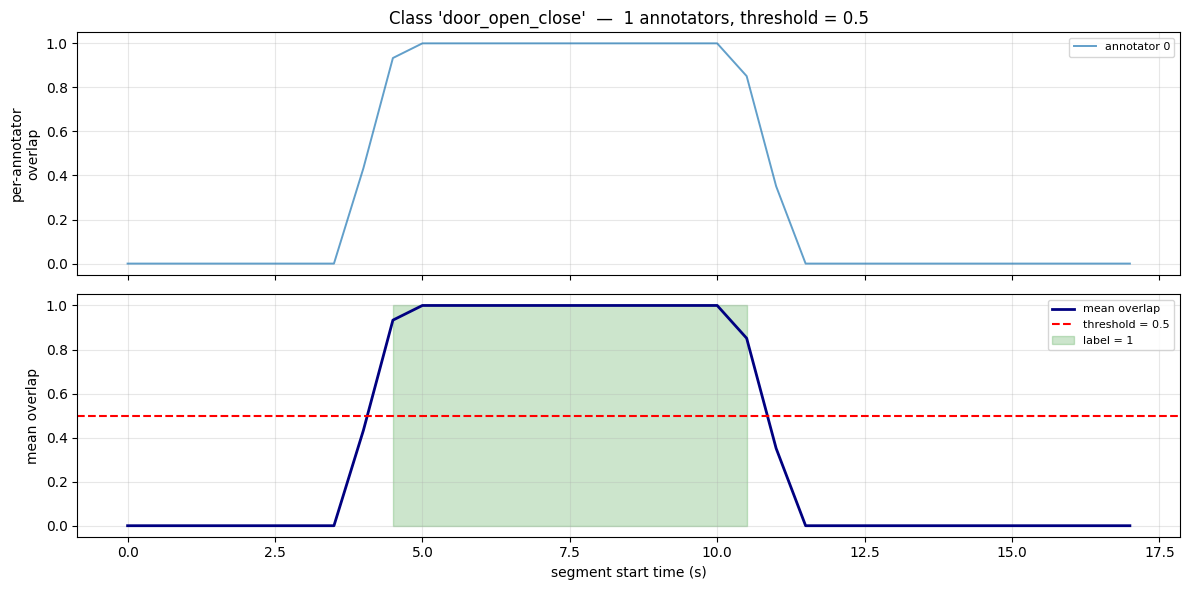


Summary for 'door_open_close':
  positive segments : 13 / 35
  positive rate     : 37.1%


In [19]:
# pick any file; the method below will auto-find a class with events
viz = AggregationVisualizer(audio_features_paths[0])

# 1) find a class that actually has annotations in this file
classIdx: int = viz.findMostActiveClass()

# 2) print the first 15 segments as a table
viz.printTable(classIdx, numRows=15)

# 3) print the most "educational" rows: where annotators disagree
viz.printInterestingRows(classIdx, k=10)

# 4) make the plot
viz.plot(classIdx)

In [20]:
X, Y = read_files(audio_features_paths[:5], label_type="multilabel")

print(f"X shape: {X.shape}    (segments × features)")
print(f"Y shape: {Y.shape}    (segments × classes)")
print(f"Y dtype: {Y.dtype}")
print(f"Y unique values: {np.unique(Y)}        (should be [0 1])")
print(f"Positive rate per class:")
for classIdx, className in enumerate(CLASSES_NAMES):
    rate: float = float(Y[:, classIdx].mean())
    print(f"  {className:30s}: {rate:.2%}")

X shape: (197, 960)    (segments × features)
Y shape: (197, 15)    (segments × classes)
Y dtype: int32
Y unique values: [0 1]        (should be [0 1])
Positive rate per class:
  bell_ringing                  : 1.52%
  coffee_machine                : 0.00%
  cutlery_dishes                : 16.24%
  door_open_close               : 9.64%
  footsteps                     : 10.66%
  keyboard_typing               : 6.09%
  keychain                      : 0.00%
  light_switch                  : 4.57%
  microwave                     : 0.00%
  phone_ringing                 : 0.51%
  running_water                 : 35.53%
  toilet_flushing               : 0.00%
  vacuum_cleaner                : 0.00%
  wardrobe_drawer_open_close    : 0.00%
  window_open_close             : 3.05%


train:  473 files
val  :  131 files
test :  127 files
OK -- no file overlap between splits
OK -- 356 collectors, each in exactly one split

class                               train        val       test
----------------------------------------------------------------
bell_ringing                       1.34%     1.26%     1.06%
coffee_machine                     5.21%     4.33%     4.61%
cutlery_dishes                     7.88%     6.71%     6.61%
door_open_close                    4.63%     3.24%     4.08%
footsteps                         13.97%    12.35%    11.93%
keyboard_typing                    8.86%     7.64%     7.44%
keychain                           5.42%     3.64%     5.18%
light_switch                       0.44%     0.41%     0.46%
microwave                          8.04%     6.90%     6.68%
phone_ringing                      6.91%     5.47%     5.96%
running_water                     15.02%    12.54%    12.00%
toilet_flushing                    2.76%     3.87%     4.19%

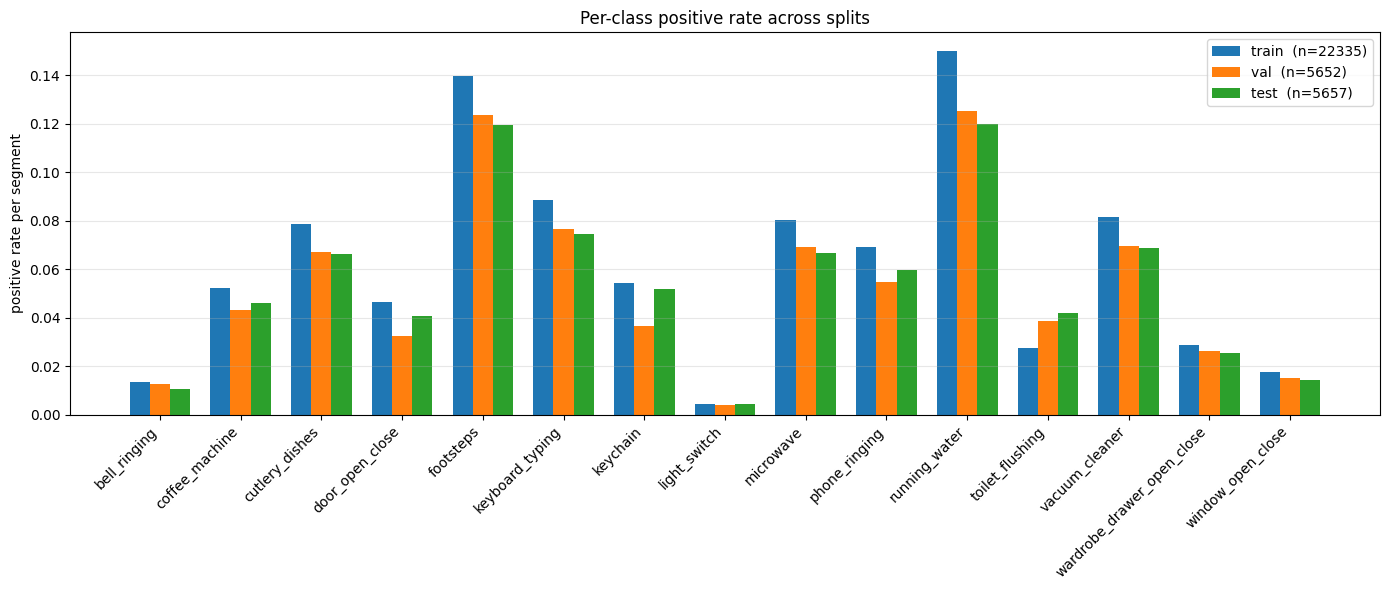

In [14]:
aggregator: LabelAggregator   = LabelAggregator()           # mean overlap, 0.5
splitter:   CollectorSplitter = CollectorSplitter(
    trainRatio=0.70,
    valRatio=0.15,
    testRatio=0.15,
    seed=42,
)

splits: Dict[str, List[str]] = splitter.split(
    filePaths=audio_features_paths,
    metadataCsvPath=str(PATH_TO_DATASET / "metadata.csv"),
    aggregator=aggregator,
)

# numbers first
for splitName, files in splits.items():
    print(f"{splitName:5s}: {len(files):4d} files")

# safety nets (both must pass)
splitter.verifyNoOverlap(splits)
splitter.verifyCollectorSeparation(splits)

# the figure for the report
splitter.plotClassDistribution(splits, aggregator)

In [20]:
meta = pd.read_csv(PATH_TO_DATASET / "metadata.csv")
print("columns :", meta.columns.tolist())
print("\nfirst 3 rows:")
print(meta.head(3))

print("\nfirst stem from your file list :", Path(audio_features_paths[0]).stem)
print("first filename in metadata    :", meta["filename"].iloc[0])

columns : ['filename', 'target_classes', 'recording_device', 'device_placement', 'recording_environment', 'scene_description', 'license', 'collector_id', 'non_target_classes']

first 3 rows:
     filename                            target_classes recording_device  \
0  003075.wav                  keyboard_typing;keychain        IPhone Xr   
1  001117.wav                                 footsteps    Iphone 15 Pro   
2  001982.wav  footsteps;door_open_close;cutlery_dishes    Surface Pro 8   

  device_placement recording_environment  \
0           static                office   
1           mobile                office   
2           static           living_room   

                                   scene_description  \
0  I was working on my laptop and playing with ke...   
1  I was walking and recorded a bird singing, car...   
2  I went to the patio door and opened it. I went...   

                          license      collector_id  \
0  CC0 (Public Domain Dedication)  04d6c4738cd1

In [22]:
collectors = set(splitter.fileToCollector_.values())
print(f"{len(collectors)} unique collectors across {len(audio_features_paths)} files")

356 unique collectors across 731 files


In [23]:
# Run the same sanity check on the full subsampled list,
# so the per-class rates reflect the real distribution.
Xfull, Yfull = read_files(audio_features_paths, label_type="multilabel")

print(f"X shape: {Xfull.shape}")
print(f"Y shape: {Yfull.shape}")
print(f"Y unique values: {np.unique(Yfull)}")

print(f"\nTotal positive segments per class:")
for classIdx, className in enumerate(CLASSES_NAMES):
    positiveCount: int   = int(Yfull[:, classIdx].sum())
    positiveRate:  float = float(Yfull[:, classIdx].mean())
    print(f"  {className:30s}: {positiveCount:5d}  ({positiveRate:.2%})")

X shape: (33644, 960)
Y shape: (33644, 15)
Y unique values: [0 1]

Total positive segments per class:
  bell_ringing                  :   431  (1.28%)
  coffee_machine                :  1669  (4.96%)
  cutlery_dishes                :  2512  (7.47%)
  door_open_close               :  1448  (4.30%)
  footsteps                     :  4493  (13.35%)
  keyboard_typing               :  2831  (8.41%)
  keychain                      :  1710  (5.08%)
  light_switch                  :   147  (0.44%)
  microwave                     :  2564  (7.62%)
  phone_ringing                 :  2189  (6.51%)
  running_water                 :  4743  (14.10%)
  toilet_flushing               :  1072  (3.19%)
  vacuum_cleaner                :  2605  (7.74%)
  wardrobe_drawer_open_close    :   936  (2.78%)
  window_open_close             :   561  (1.67%)



class                               train        val       test
----------------------------------------------------------------
bell_ringing                       1.34%     1.26%     1.06%
coffee_machine                     5.21%     4.33%     4.61%
cutlery_dishes                     7.88%     6.71%     6.61%
door_open_close                    4.63%     3.24%     4.08%
footsteps                         13.97%    12.35%    11.93%
keyboard_typing                    8.86%     7.64%     7.44%
keychain                           5.42%     3.64%     5.18%
light_switch                       0.44%     0.41%     0.46%
microwave                          8.04%     6.90%     6.68%
phone_ringing                      6.91%     5.47%     5.96%
running_water                     15.02%    12.54%    12.00%
toilet_flushing                    2.76%     3.87%     4.19%
vacuum_cleaner                     8.15%     6.97%     6.89%
wardrobe_drawer_open_close         2.89%     2.62%     2.53%
window_open_clos

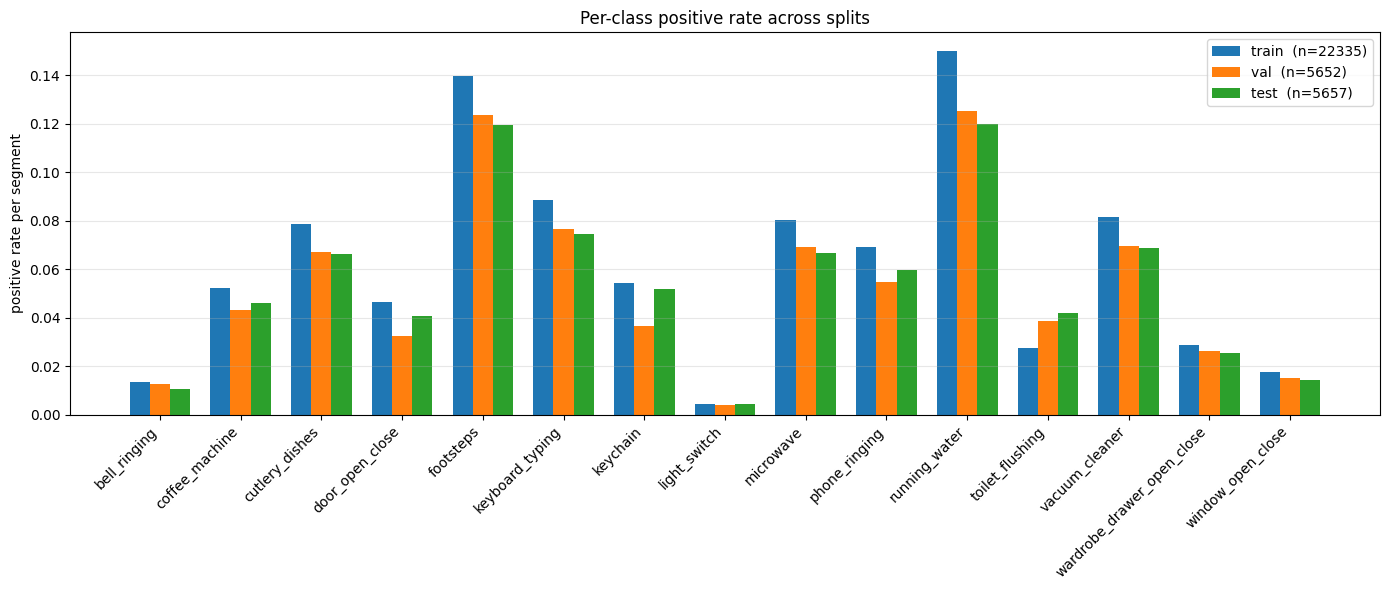

In [24]:
splitter.plotClassDistribution(splits, aggregator)

In [17]:
#old
def get_features_and_targets(
    filename: str,
    label_type: Literal["binary", "multiclass", "multilabel"] = "multilabel",
) -> Tuple[np.ndarray, Union[np.ndarray, Dict[str, np.ndarray]]]:
    """Load audio features and aggregated target labels from a .npz file.

    Parameters
    ----------
    filename : str
        Path to the .npz file containing audio features and annotations.
    label_type : {"binary", "multiclass", "multilabel"}
        How to encode the targets:
        - "multilabel": binary matrix of shape (T, C), one column per class.
        - "multiclass": integer class index of shape (T, 1), argmax over classes.
        - "binary": dict mapping each class name to a binary array of shape (T, 1).

    Returns
    -------
    x : np.ndarray of shape (T, D)
        Feature matrix with T time frames and D feature dimensions.
    y : np.ndarray of shape (T, C) or (T, 1), or Dict[str, np.ndarray]
        Labels in the format specified by ``label_type``.
    """
    audio_features = dict(np.load(filename, allow_pickle=True))
    annotations = audio_features["annotations"]
    T, C, _ = annotations.shape

    # Concatenate all features
    x = np.empty(
        (
            T,
            sum(
                audio_features[f].shape[1] if audio_features[f].ndim > 1 else 1
                for f in FEATURE_NAMES
            ),
        )
    )
    col = 0
    for feat_name in FEATURE_NAMES:
        feat = audio_features[feat_name]
        width = feat.shape[1] if feat.ndim > 1 else 1
        x[:, col : col + width] = feat if feat.ndim > 1 else feat[:, None]
        col += width

    # Majority-vote aggregation across annotators
    annotations = (annotations > 0).astype(int) # this threshold could be improved
    votes = annotations.sum(axis=2)  # (T, C)

    if label_type == "multilabel":
        y = (votes > (annotations.shape[-1] // 2)).astype(int)
    elif label_type == "multiclass":
        y = np.argmax(votes, axis=1).astype(int).reshape(T, 1)
    else:  # "binary"
        y = make_binary_targets((votes > (annotations.shape[-1] // 2)).astype(int))

    return x, y


def make_binary_targets(Y: np.ndarray) -> Dict[str, np.ndarray]:
    """Convert a multilabel indicator matrix into per-class binary arrays.

    Parameters
    ----------
    Y : np.ndarray of shape (N, C)
        Binary multilabel matrix with N frames and C classes.

    Returns
    -------
    Y_binary : dict of {str: np.ndarray}
        Dictionary mapping each class name in ``CLASSES_NAMES`` to a binary
        array of shape (N, 1).
    """
    return {
        class_name: Y[:, idx].reshape(-1, 1).astype(int)
        for idx, class_name in enumerate(CLASSES_NAMES)
    }

In [26]:
from sklearn.preprocessing import StandardScaler
import numpy as np


class FeatureNormalizer:
    """
    Standardizes features to zero mean and unit variance.

    Designed for the train / val / test workflow: the fit() method
    must be called on the training matrix exactly once. After that,
    transform() can be applied to any matrix (train, val, test, or
    new files) using the SAME statistics learned from training.

    Calling transform() before fit() raises an error -- this is the
    whole point of the wrapper.
    """

    def __init__(self) -> None:
        self.scaler:    StandardScaler = StandardScaler()
        self.isFitted_: bool           = False
        self.numFeatures_: int         = -1

    # ---- public API ----
    def fit(self, xTrain: np.ndarray) -> "FeatureNormalizer":
        if xTrain.ndim != 2:
            raise ValueError(f"expected 2D [N, D], got shape {xTrain.shape}")
        self.scaler.fit(xTrain)
        self.isFitted_    = True
        self.numFeatures_ = xTrain.shape[1]
        return self

    def transform(self, x: np.ndarray) -> np.ndarray:
        if not self.isFitted_:
            raise RuntimeError(
                "FeatureNormalizer.transform() called before fit(). "
                "Always fit on the training data first."
            )
        if x.shape[1] != self.numFeatures_:
            raise ValueError(
                f"expected {self.numFeatures_} features, got {x.shape[1]}"
            )
        return self.scaler.transform(x)

    def fitTransform(self, xTrain: np.ndarray) -> np.ndarray:
        return self.fit(xTrain).transform(xTrain)

    # ---- introspection (handy for the report) ----
    @property
    def means(self) -> np.ndarray:
        self._assertFitted()
        return self.scaler.mean_

    @property
    def stds(self) -> np.ndarray:
        self._assertFitted()
        return self.scaler.scale_

    def _assertFitted(self) -> None:
        if not self.isFitted_:
            raise RuntimeError("FeatureNormalizer is not fitted yet")

In [25]:
# Reuse the splits you built in 1.b
X_train, Y_train = read_files(splits["train"], label_type="multilabel", aggregator=aggregator)
X_val,   Y_val   = read_files(splits["val"],   label_type="multilabel", aggregator=aggregator)
X_test,  Y_test  = read_files(splits["test"],  label_type="multilabel", aggregator=aggregator)

normalizer: FeatureNormalizer = FeatureNormalizer()

X_train_z: np.ndarray = normalizer.fitTransform(X_train)   # fit + transform
X_val_z:   np.ndarray = normalizer.transform(X_val)        # transform only
X_test_z:  np.ndarray = normalizer.transform(X_test)       # transform only

In [27]:
print("Before scaling (training set):")
print(f"  per-feature means:  min={X_train.mean(axis=0).min():>10.3f}, "
      f"max={X_train.mean(axis=0).max():>10.3f}")
print(f"  per-feature stds :  min={X_train.std(axis=0).min():>10.3f}, "
      f"max={X_train.std(axis=0).max():>10.3f}")

print("\nAfter scaling (training set):")
print(f"  per-feature means:  min={X_train_z.mean(axis=0).min():>10.6f}, "
      f"max={X_train_z.mean(axis=0).max():>10.6f}")
print(f"  per-feature stds :  min={X_train_z.std(axis=0).min():>10.6f}, "
      f"max={X_train_z.std(axis=0).max():>10.6f}")

print("\nAfter scaling (validation set — should be CLOSE to zero/one but not exact):")
print(f"  per-feature means:  min={X_val_z.mean(axis=0).min():>10.6f}, "
      f"max={X_val_z.mean(axis=0).max():>10.6f}")
print(f"  per-feature stds :  min={X_val_z.std(axis=0).min():>10.6f}, "
      f"max={X_val_z.std(axis=0).max():>10.6f}")

Before scaling (training set):
  per-feature means:  min=   -88.184, max=  6414.947
  per-feature stds :  min=     0.002, max=  1819.225

After scaling (training set):
  per-feature means:  min= -0.000000, max=  0.000000
  per-feature stds :  min=  1.000000, max=  1.000000

After scaling (validation set — should be CLOSE to zero/one but not exact):
  per-feature means:  min= -0.140526, max=  0.114195
  per-feature stds :  min=  0.689821, max=  1.296196


In [16]:
from sklearn.metrics import f1_score
from typing import Dict
import numpy as np


class MetricEvaluator:
    """
    Computes macro F1 for multi-label classification.

    Macro F1 is computed as the unweighted mean of per-class F1 scores.
    Every class contributes equally regardless of how frequent it is --
    that is the property we want for severely imbalanced data.
    """

    # ---- public API ----
    def computeMacroF1(self, yTrue: np.ndarray, yPred: np.ndarray) -> float:
        self._assertShape(yTrue, yPred)
        return float(f1_score(yTrue, yPred, average="macro", zero_division=0))

    def computePerClassF1(self, yTrue: np.ndarray, yPred: np.ndarray) -> Dict[str, float]:
        self._assertShape(yTrue, yPred)
        scores: np.ndarray = f1_score(yTrue, yPred, average=None, zero_division=0)
        return {className: float(s) for className, s in zip(CLASSES_NAMES, scores)}

    def printReport(
        self,
        yTrue: np.ndarray,
        yPred: np.ndarray,
        name:  str = "model",
    ) -> None:
        macroF1:  float            = self.computeMacroF1(yTrue, yPred)
        perClass: Dict[str, float] = self.computePerClassF1(yTrue, yPred)

        print(f"\n=== {name} ===")
        print(f"Macro F1: {macroF1:.4f}")
        print(f"Per-class F1:")
        for className, score in perClass.items():
            print(f"  {className:30s}: {score:.4f}")

    # ---- private helpers ----
    @staticmethod
    def _assertShape(yTrue: np.ndarray, yPred: np.ndarray) -> None:
        if yTrue.shape != yPred.shape:
            raise ValueError(
                f"shape mismatch: yTrue={yTrue.shape}, yPred={yPred.shape}"
            )
        if yTrue.ndim != 2:
            raise ValueError(
                f"expected 2D multi-label arrays [N, C], got {yTrue.shape}"
            )

In [23]:
from enum import Enum
from sklearn.base import BaseEstimator, ClassifierMixin


class BaselineStrategy(Enum):
    """Two non-learning strategies for the baseline."""
    ALWAYS_NEGATIVE   = "always_negative"     # predict 0 everywhere
    STRATIFIED_RANDOM = "stratified_random"   # Bernoulli at training rate


class MultilabelBaseline(BaseEstimator, ClassifierMixin):
    """
    A non-learning multi-label baseline.

    ALWAYS_NEGATIVE   : predicts 0 for every (segment, class) pair.
                        Gives macro F1 = 0 by construction. This is the
                        absolute floor.
    STRATIFIED_RANDOM : for each class c, predicts 1 with probability
                        equal to the empirical positive rate of class c
                        in the training set. Slightly above zero macro F1.

    Neither strategy looks at the feature matrix X -- only at the training
    label statistics. That is by design: the baseline tells you what you
    can achieve without learning anything from the features.
    """

    # ---- constructor ----
    def __init__(
        self,
        strategy: BaselineStrategy = BaselineStrategy.STRATIFIED_RANDOM,
        seed:     int               = 42,
    ) -> None:
        self.strategy:    BaselineStrategy = strategy
        self.seed:        int               = seed
        self.classRates_: np.ndarray       = None    # set during fit()
        self.numClasses_: int               = -1

    # ---- sklearn-style API ----
    def fit(self, X: np.ndarray, Y: np.ndarray) -> "MultilabelBaseline":
        if Y.ndim != 2:
            raise ValueError(f"expected 2D labels [N, C], got shape {Y.shape}")
        self.numClasses_ = Y.shape[1]
        self.classRates_ = Y.mean(axis=0).astype(float)   # one rate per class
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.classRates_ is None:
            raise RuntimeError("call fit(...) before predict(...)")

        numSamples: int        = X.shape[0]
        predictions: np.ndarray = np.zeros(
            (numSamples, self.numClasses_), dtype=np.int32
        )

        if self.strategy == BaselineStrategy.ALWAYS_NEGATIVE:
            return predictions

        elif self.strategy == BaselineStrategy.STRATIFIED_RANDOM:
            rng = np.random.default_rng(self.seed)
            for classIdx in range(self.numClasses_):
                rate: float = float(self.classRates_[classIdx])
                predictions[:, classIdx] = (
                    rng.random(numSamples) < rate
                ).astype(np.int32)
            return predictions

        else:
            raise ValueError(f"unknown strategy: {self.strategy}")

In [27]:
evaluator: MetricEvaluator = MetricEvaluator()

# --- Baseline 1: always predict 0 ---
baselineAlwaysNeg: MultilabelBaseline = MultilabelBaseline(
    strategy=BaselineStrategy.ALWAYS_NEGATIVE,
).fit(X_train_z, Y_train)

yPredAlwaysNeg: np.ndarray = baselineAlwaysNeg.predict(X_val_z)
evaluator.printReport(Y_val, yPredAlwaysNeg, name="Baseline: always negative")

# --- Baseline 2: stratified random ---
baselineStratified: MultilabelBaseline = MultilabelBaseline(
    strategy=BaselineStrategy.STRATIFIED_RANDOM,
    seed=42,
).fit(X_train_z, Y_train)

yPredStratified: np.ndarray = baselineStratified.predict(X_val_z)
evaluator.printReport(Y_val, yPredStratified, name="Baseline: stratified random")

# --- summary line for the report ---
print("\n=== Summary ===")
print(f"Always-negative baseline   macro F1 = "
      f"{evaluator.computeMacroF1(Y_val, yPredAlwaysNeg):.4f}")
print(f"Stratified random baseline macro F1 = "
      f"{evaluator.computeMacroF1(Y_val, yPredStratified):.4f}")


=== Baseline: always negative ===
Macro F1: 0.0000
Per-class F1:
  bell_ringing                  : 0.0000
  coffee_machine                : 0.0000
  cutlery_dishes                : 0.0000
  door_open_close               : 0.0000
  footsteps                     : 0.0000
  keyboard_typing               : 0.0000
  keychain                      : 0.0000
  light_switch                  : 0.0000
  microwave                     : 0.0000
  phone_ringing                 : 0.0000
  running_water                 : 0.0000
  toilet_flushing               : 0.0000
  vacuum_cleaner                : 0.0000
  wardrobe_drawer_open_close    : 0.0000
  window_open_close             : 0.0000

=== Baseline: stratified random ===
Macro F1: 0.0552
Per-class F1:
  bell_ringing                  : 0.0141
  coffee_machine                : 0.0255
  cutlery_dishes                : 0.0527
  door_open_close               : 0.0308
  footsteps                     : 0.1268
  keyboard_typing               : 0.0971
  key

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from typing import Optional
import numpy as np


class RandomForestModel:
    """
    Multi-label Random Forest wrapper around sklearn's RandomForestClassifier
    with two production-style additions:

      * 'class_weight=balanced' is set automatically -- training samples are
        re-weighted by inverse class frequency so the rare classes
        (e.g. light_switch at 0.4%) are not ignored.

      * Per-class probability thresholds are stored on the model and tuned
        on validation data via tuneThresholds(...). The default threshold
        for every class is 0.5.

    Predict pipeline:
       X -> predictProba() -> [N, C] of P(class=1)
                            -> (probs >= self.thresholds_) -> [N, C] of {0, 1}
    """

    # ---- public static final defaults ----
    DEFAULT_N_ESTIMATORS:     int = 200
    DEFAULT_MAX_DEPTH:        Optional[int] = None       # unlimited
    DEFAULT_MIN_SAMPLES_LEAF: int = 1
    DEFAULT_MAX_FEATURES:     str = "sqrt"
    DEFAULT_SEED:             int = 42
    DEFAULT_N_JOBS:           int = -1                    # use all cores

    # ---- constructor ----
    def __init__(
        self,
        nEstimators:     int           = DEFAULT_N_ESTIMATORS,
        maxDepth:        Optional[int] = DEFAULT_MAX_DEPTH,
        minSamplesLeaf:  int           = DEFAULT_MIN_SAMPLES_LEAF,
        maxFeatures:     str           = DEFAULT_MAX_FEATURES,
        seed:            int           = DEFAULT_SEED,
        nJobs:           int           = DEFAULT_N_JOBS,
    ) -> None:
        self.nEstimators:    int           = nEstimators
        self.maxDepth:       Optional[int] = maxDepth
        self.minSamplesLeaf: int           = minSamplesLeaf
        self.maxFeatures:    str           = maxFeatures
        self.seed:           int           = seed
        self.nJobs:          int           = nJobs

        self.model_:       Optional[RandomForestClassifier] = None
        self.thresholds_:  Optional[np.ndarray]             = None
        self.numClasses_:  int                              = -1
        self.isFitted_:    bool                             = False

    # ---- training ----
    def fit(self, X: np.ndarray, Y: np.ndarray) -> "RandomForestModel":
        if X.ndim != 2 or Y.ndim != 2:
            raise ValueError(
                f"expected X=[N,D] and Y=[N,C], got X={X.shape}, Y={Y.shape}"
            )

        self.model_ = RandomForestClassifier(
            n_estimators       = self.nEstimators,
            max_depth          = self.maxDepth,
            min_samples_leaf   = self.minSamplesLeaf,
            max_features       = self.maxFeatures,
            class_weight       = "balanced",
            random_state       = self.seed,
            n_jobs             = self.nJobs,
        )
        self.model_.fit(X, Y)

        self.numClasses_ = Y.shape[1]
        self.thresholds_ = np.full(self.numClasses_, 0.5, dtype=np.float64)
        self.isFitted_   = True
        return self

    # ---- prediction ----
    def predictProba(self, X: np.ndarray) -> np.ndarray:
        """Returns [N, C] positive-class probabilities."""
        self._assertFitted()

        rawProbs = self.model_.predict_proba(X)
        if not isinstance(rawProbs, list):
            rawProbs = [rawProbs]

        numSamples: int = X.shape[0]
        result: np.ndarray = np.zeros(
            (numSamples, self.numClasses_), dtype=np.float64
        )

        classesList = self.model_.classes_
        for classIdx in range(self.numClasses_):
            classProbs    = rawProbs[classIdx]
            outputClasses = classesList[classIdx] if isinstance(classesList, list) else classesList

            if classProbs.shape[1] == 1:
                # only one class seen in training for this output
                result[:, classIdx] = 1.0 if int(outputClasses[0]) == 1 else 0.0
            else:
                posCol: int = int(np.where(outputClasses == 1)[0][0])
                result[:, classIdx] = classProbs[:, posCol]
        return result

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Returns [N, C] binary predictions using the per-class thresholds."""
        probs: np.ndarray = self.predictProba(X)
        return (probs >= self.thresholds_).astype(np.int32)

    # ---- threshold tuning ----
    def tuneThresholds(
        self,
        X_val: np.ndarray,
        Y_val: np.ndarray,
        gridSize: int = 19,
    ) -> np.ndarray:
        """
        Find the threshold per class that maximises F1 on the validation set.

        Returns the new threshold array of shape [C]; the model is also
        updated in-place so that subsequent predict() calls use them.
        """
        self._assertFitted()
        if Y_val.shape[1] != self.numClasses_:
            raise ValueError(
                f"Y_val has {Y_val.shape[1]} columns, model has {self.numClasses_}"
            )

        probs: np.ndarray = self.predictProba(X_val)
        thresholdGrid: np.ndarray = np.linspace(0.05, 0.95, gridSize)
        newThresholds: np.ndarray = np.full(self.numClasses_, 0.5, dtype=np.float64)

        for classIdx in range(self.numClasses_):
            bestF1:        float = -1.0
            bestThreshold: float = 0.5
            for threshold in thresholdGrid:
                preds: np.ndarray = (probs[:, classIdx] >= threshold).astype(np.int32)
                f1: float = float(f1_score(
                    Y_val[:, classIdx], preds, zero_division=0
                ))
                if f1 > bestF1:
                    bestF1        = f1
                    bestThreshold = float(threshold)
            newThresholds[classIdx] = bestThreshold

        self.thresholds_ = newThresholds
        return newThresholds

    # ---- introspection ----
    def getFeatureImportances(self) -> np.ndarray:
        self._assertFitted()
        return self.model_.feature_importances_

    def getThresholds(self) -> np.ndarray:
        self._assertFitted()
        return self.thresholds_.copy()

    # ---- private ----
    def _assertFitted(self) -> None:
        if not self.isFitted_:
            raise RuntimeError("call fit(...) before predict()/predictProba()")

In [29]:
import time

# --- Train ---
print("Training Random Forest ...")
t0 = time.time()
rf: RandomForestModel = RandomForestModel(
    nEstimators=200,
    maxDepth=None,
    minSamplesLeaf=1,
).fit(X_train_z, Y_train)
print(f"  done in {time.time() - t0:.1f}s")

# --- Evaluate with default 0.5 thresholds ---
yPredDefault: np.ndarray = rf.predict(X_val_z)
macroF1_default: float = evaluator.computeMacroF1(Y_val, yPredDefault)
print(f"\nRF with default thresholds: macro F1 = {macroF1_default:.4f}")

# --- Tune thresholds on validation set ---
print("\nTuning per-class thresholds on validation set ...")
tunedThresholds: np.ndarray = rf.tuneThresholds(X_val_z, Y_val)

yPredTuned: np.ndarray = rf.predict(X_val_z)
macroF1_tuned: float = evaluator.computeMacroF1(Y_val, yPredTuned)
print(f"RF with tuned thresholds  : macro F1 = {macroF1_tuned:.4f}")

# --- Per-class breakdown for the report ---
evaluator.printReport(Y_val, yPredTuned, name="Random Forest (tuned)")

# --- Show how the thresholds shifted ---
print("\nTuned thresholds per class:")
for classIdx, className in enumerate(CLASSES_NAMES):
    print(f"  {className:30s}: {tunedThresholds[classIdx]:.2f}")

Training Random Forest ...


KeyboardInterrupt: 

In [33]:
import time
from typing import Dict, List, Optional, Tuple, Any
import matplotlib.pyplot as plt


class HyperparameterSweeper:
    """
    Sweeps one hyperparameter of RandomForestModel at a time, recording
    macro F1 on train and validation at every value, then plots both
    curves on a shared axis. Repeatable for multiple hyperparameters.

    For each value of the swept parameter:
      1) Fit RandomForestModel on (X_train, Y_train).
      2) Tune per-class probability thresholds on (X_val, Y_val).
      3) Predict on train and val using those tuned thresholds.
      4) Record macro F1 for train and val, plus the fit time.
    """

    # ---- constructor ----
    def __init__(
        self,
        X_train:    np.ndarray,
        Y_train:    np.ndarray,
        X_val:      np.ndarray,
        Y_val:      np.ndarray,
        evaluator:  "MetricEvaluator",
    ) -> None:
        self.X_train:   np.ndarray       = X_train
        self.Y_train:   np.ndarray       = Y_train
        self.X_val:     np.ndarray       = X_val
        self.Y_val:     np.ndarray       = Y_val
        self.evaluator: MetricEvaluator  = evaluator

        # paramName -> {param_values, train_f1, val_f1, fit_times}
        self.results_: Dict[str, Dict[str, list]] = {}

    # ---- public API ----
    def sweep(
        self,
        paramName:    str,
        paramValues:  List[Any],
        baseParams:   Optional[Dict[str, Any]] = None,
    ) -> Dict[str, list]:
        """Run one full sweep. Returns results dict, also stored on self."""
        if baseParams is None:
            baseParams = {}

        trainF1s:  List[float] = []
        valF1s:    List[float] = []
        fitTimes:  List[float] = []

        print(f"\nSweeping {paramName} over {paramValues}")
        for value in paramValues:
            params: Dict[str, Any] = dict(baseParams)
            params[paramName] = value

            tStart: float = time.time()
            model: RandomForestModel = RandomForestModel(**params).fit(
                self.X_train, self.Y_train
            )
            model.tuneThresholds(self.X_val, self.Y_val)
            fitTime: float = time.time() - tStart

            yPredTrain: np.ndarray = model.predict(self.X_train)
            yPredVal:   np.ndarray = model.predict(self.X_val)

            trainF1: float = self.evaluator.computeMacroF1(self.Y_train, yPredTrain)
            valF1:   float = self.evaluator.computeMacroF1(self.Y_val,   yPredVal)

            trainF1s.append(trainF1)
            valF1s.append(valF1)
            fitTimes.append(fitTime)

            print(
                f"  {paramName}={str(value):>6s}  "
                f"train F1={trainF1:.4f}  val F1={valF1:.4f}  "
                f"({fitTime:.1f}s)"
            )

        result: Dict[str, list] = {
            "param_name":   paramName,
            "param_values": paramValues,
            "train_f1":     trainF1s,
            "val_f1":       valF1s,
            "fit_times":    fitTimes,
        }
        self.results_[paramName] = result
        return result

    def plot(self, paramName: str, ax=None) -> None:
        if paramName not in self.results_:
            raise ValueError(f"no sweep results for {paramName!r}")
        r:      Dict[str, list] = self.results_[paramName]
        values: list            = r["param_values"]

        # Render None nicely on the x-axis (for max_depth=None)
        labels: List[str] = ["None" if v is None else str(v) for v in values]
        xPositions: np.ndarray = np.arange(len(values))

        if ax is None:
            _, ax = plt.subplots(figsize=(8, 5))

        ax.plot(xPositions, r["train_f1"], marker="o", linewidth=2, label="train")
        ax.plot(xPositions, r["val_f1"],   marker="s", linewidth=2, label="validation")

        # mark the best validation point
        bestIdx: int = int(np.argmax(r["val_f1"]))
        ax.axvline(bestIdx, color="grey", linestyle=":", alpha=0.6)
        ax.scatter(
            [bestIdx], [r["val_f1"][bestIdx]],
            s=180, facecolors="none", edgecolors="red", linewidths=2,
            label=f"best val: {r['val_f1'][bestIdx]:.3f}",
        )

        ax.set_xticks(xPositions)
        ax.set_xticklabels(labels)
        ax.set_xlabel(paramName)
        ax.set_ylabel("macro F1")
        ax.set_title(f"Random Forest -- macro F1 vs {paramName}")
        ax.set_ylim(0.0, 1.05)
        ax.legend(loc="lower right")
        ax.grid(alpha=0.3)

    def plotAll(self) -> None:
        if not self.results_:
            raise RuntimeError("no sweeps to plot yet")
        numPlots: int = len(self.results_)
        fig, axes = plt.subplots(1, numPlots, figsize=(7 * numPlots, 5))
        if numPlots == 1:
            axes = [axes]
        for ax, paramName in zip(axes, self.results_.keys()):
            self.plot(paramName, ax=ax)
        plt.tight_layout()
        plt.show()

    def getBestValue(self, paramName: str) -> Tuple[Any, float]:
        if paramName not in self.results_:
            raise ValueError(f"no sweep for {paramName!r}")
        r:        Dict[str, list] = self.results_[paramName]
        bestIdx:  int             = int(np.argmax(r["val_f1"]))
        return r["param_values"][bestIdx], float(r["val_f1"][bestIdx])

    def printBestValues(self) -> None:
        print("\n=== Best validation F1 per hyperparameter ===")
        for paramName in self.results_:
            bestVal, bestF1 = self.getBestValue(paramName)
            print(f"  {paramName:20s}: best={bestVal}, val F1={bestF1:.4f}")

In [30]:
import time
from typing import Dict, List, Optional, Tuple, Any
import matplotlib.pyplot as plt


class HyperparameterSweeper:
    """
    Sweeps one hyperparameter of RandomForestModel at a time, recording
    macro F1 on train and validation at every value, then plots both
    curves on a shared axis. Repeatable for multiple hyperparameters.

    For each value of the swept parameter:
      1) Fit RandomForestModel on (X_train, Y_train).
      2) Tune per-class probability thresholds on (X_val, Y_val).
      3) Predict on train and val using those tuned thresholds.
      4) Record macro F1 for train and val, plus the fit time.
    """

    # ---- constructor ----
    def __init__(
        self,
        X_train:    np.ndarray,
        Y_train:    np.ndarray,
        X_val:      np.ndarray,
        Y_val:      np.ndarray,
        evaluator:  "MetricEvaluator",
    ) -> None:
        self.X_train:   np.ndarray       = X_train
        self.Y_train:   np.ndarray       = Y_train
        self.X_val:     np.ndarray       = X_val
        self.Y_val:     np.ndarray       = Y_val
        self.evaluator: MetricEvaluator  = evaluator

        # paramName -> {param_values, train_f1, val_f1, fit_times}
        self.results_: Dict[str, Dict[str, list]] = {}

    # ---- public API ----
    def sweep(
    self,
    paramName:    str,
    paramValues:  List[Any],
    baseParams:   Optional[Dict[str, Any]] = None,
    modelClass:   type = None,                # NEW
) -> Dict[str, list]:
        """Run one full sweep. Returns results dict, also stored on self."""
        if baseParams is None:
            baseParams = {}
        if modelClass is None:
            modelClass = RandomForestModel              # default keeps old behaviour
    
        trainF1s:  List[float] = []
        valF1s:    List[float] = []
        fitTimes:  List[float] = []
    
        print(f"\nSweeping {paramName} over {paramValues}  [{modelClass.__name__}]")
        for value in paramValues:
            params: Dict[str, Any] = dict(baseParams)
            params[paramName] = value
    
            tStart: float = time.time()
            model = modelClass(**params).fit(self.X_train, self.Y_train)    # CHANGED
            model.tuneThresholds(self.X_val, self.Y_val)
            fitTime: float = time.time() - tStart
    
            yPredTrain: np.ndarray = model.predict(self.X_train)
            yPredVal:   np.ndarray = model.predict(self.X_val)
    
            trainF1: float = self.evaluator.computeMacroF1(self.Y_train, yPredTrain)
            valF1:   float = self.evaluator.computeMacroF1(self.Y_val,   yPredVal)
    
            trainF1s.append(trainF1)
            valF1s.append(valF1)
            fitTimes.append(fitTime)
    
            print(
                f"  {paramName}={str(value):>8s}  "
                f"train F1={trainF1:.4f}  val F1={valF1:.4f}  "
                f"({fitTime:.1f}s)"
            )
    
        result: Dict[str, list] = {
            "param_name":   paramName,
            "param_values": paramValues,
            "train_f1":     trainF1s,
            "val_f1":       valF1s,
            "fit_times":    fitTimes,
        }
        self.results_[paramName] = result
        return result

    def plot(self, paramName: str, ax=None) -> None:
        if paramName not in self.results_:
            raise ValueError(f"no sweep results for {paramName!r}")
        r:      Dict[str, list] = self.results_[paramName]
        values: list            = r["param_values"]

        # Render None nicely on the x-axis (for max_depth=None)
        labels: List[str] = ["None" if v is None else str(v) for v in values]
        xPositions: np.ndarray = np.arange(len(values))

        if ax is None:
            _, ax = plt.subplots(figsize=(8, 5))

        ax.plot(xPositions, r["train_f1"], marker="o", linewidth=2, label="train")
        ax.plot(xPositions, r["val_f1"],   marker="s", linewidth=2, label="validation")

        # mark the best validation point
        bestIdx: int = int(np.argmax(r["val_f1"]))
        ax.axvline(bestIdx, color="grey", linestyle=":", alpha=0.6)
        ax.scatter(
            [bestIdx], [r["val_f1"][bestIdx]],
            s=180, facecolors="none", edgecolors="red", linewidths=2,
            label=f"best val: {r['val_f1'][bestIdx]:.3f}",
        )

        ax.set_xticks(xPositions)
        ax.set_xticklabels(labels)
        ax.set_xlabel(paramName)
        ax.set_ylabel("macro F1")
        ax.set_title(f"Random Forest -- macro F1 vs {paramName}")
        ax.set_ylim(0.0, 1.05)
        ax.legend(loc="lower right")
        ax.grid(alpha=0.3)

    def plotAll(self) -> None:
        if not self.results_:
            raise RuntimeError("no sweeps to plot yet")
        numPlots: int = len(self.results_)
        fig, axes = plt.subplots(1, numPlots, figsize=(7 * numPlots, 5))
        if numPlots == 1:
            axes = [axes]
        for ax, paramName in zip(axes, self.results_.keys()):
            self.plot(paramName, ax=ax)
        plt.tight_layout()
        plt.show()

    def getBestValue(self, paramName: str) -> Tuple[Any, float]:
        if paramName not in self.results_:
            raise ValueError(f"no sweep for {paramName!r}")
        r:        Dict[str, list] = self.results_[paramName]
        bestIdx:  int             = int(np.argmax(r["val_f1"]))
        return r["param_values"][bestIdx], float(r["val_f1"][bestIdx])

    def printBestValues(self) -> None:
        print("\n=== Best validation F1 per hyperparameter ===")
        for paramName in self.results_:
            bestVal, bestF1 = self.getBestValue(paramName)
            print(f"  {paramName:20s}: best={bestVal}, val F1={bestF1:.4f}")


Sweeping nEstimators over [25, 50, 100, 200, 400]
  nEstimators=    25  train F1=0.9635  val F1=0.3950  (8.0s)
  nEstimators=    50  train F1=0.9695  val F1=0.4243  (28.5s)
  nEstimators=   100  train F1=0.9762  val F1=0.4382  (56.8s)
  nEstimators=   200  train F1=0.9826  val F1=0.4475  (111.5s)
  nEstimators=   400  train F1=0.9826  val F1=0.4501  (223.0s)

Sweeping maxDepth over [5, 10, 15, 20, 30, None]
  maxDepth=     5  train F1=0.3225  val F1=0.2497  (15.9s)
  maxDepth=    10  train F1=0.4991  val F1=0.3382  (28.9s)
  maxDepth=    15  train F1=0.7611  val F1=0.3782  (41.3s)
  maxDepth=    20  train F1=0.8643  val F1=0.4160  (48.0s)
  maxDepth=    30  train F1=0.9453  val F1=0.4268  (52.9s)
  maxDepth=  None  train F1=0.9762  val F1=0.4382  (55.9s)

Sweeping minSamplesLeaf over [1, 2, 5, 10, 20, 50]
  minSamplesLeaf=     1  train F1=0.9762  val F1=0.4382  (55.9s)
  minSamplesLeaf=     2  train F1=0.9419  val F1=0.4286  (53.7s)
  minSamplesLeaf=     5  train F1=0.8641  val F1=0.4

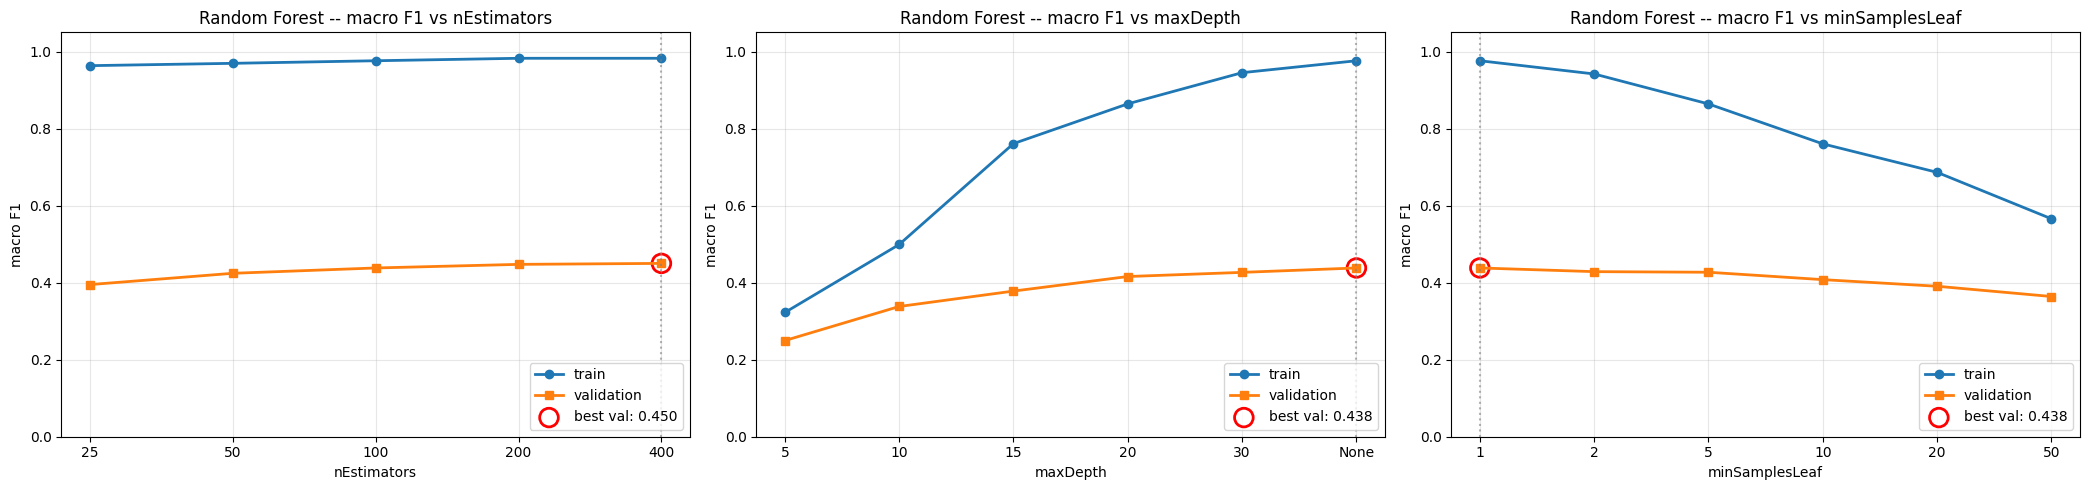


=== Best validation F1 per hyperparameter ===
  nEstimators         : best=400, val F1=0.4501
  maxDepth            : best=None, val F1=0.4382
  minSamplesLeaf      : best=1, val F1=0.4382


In [34]:
sweeper: HyperparameterSweeper = HyperparameterSweeper(
    X_train=X_train_z,
    Y_train=Y_train,
    X_val=X_val_z,
    Y_val=Y_val,
    evaluator=evaluator,
)

# Sweep 1: number of trees
sweeper.sweep(
    paramName="nEstimators",
    paramValues=[25, 50, 100, 200, 400],
    baseParams={"maxDepth": None, "minSamplesLeaf": 1},
)

# Sweep 2: tree depth  (use 100 trees here to keep sweep time reasonable)
sweeper.sweep(
    paramName="maxDepth",
    paramValues=[5, 10, 15, 20, 30, None],
    baseParams={"nEstimators": 100, "minSamplesLeaf": 1},
)

# Sweep 3: minimum samples per leaf
sweeper.sweep(
    paramName="minSamplesLeaf",
    paramValues=[1, 2, 5, 10, 20, 50],
    baseParams={"nEstimators": 100, "maxDepth": None},
)

# Plots & summary
sweeper.plotAll()
sweeper.printBestValues()

In [31]:
finalRF: RandomForestModel = RandomForestModel(
    nEstimators=200,
    maxDepth=None,
    minSamplesLeaf=1,
    maxFeatures="sqrt",
    seed=42,
).fit(X_train_z, Y_train)

finalRF.tuneThresholds(X_val_z, Y_val)

# Confirm we land where we expect
yPredFinal: np.ndarray = finalRF.predict(X_val_z)
print(f"Final RF val macro F1: {evaluator.computeMacroF1(Y_val, yPredFinal):.4f}")

Final RF val macro F1: 0.4475


In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from typing import Optional
import numpy as np


class KNNModel:
    """
    Multi-label k-Nearest Neighbours classifier with per-class threshold
    tuning. Designed as a drop-in twin of RandomForestModel.

    Notes on imbalance:
        KNN does not have `class_weight='balanced'` -- the class is rebalanced
        implicitly by (a) using `weights='distance'` so close neighbours
        dominate the vote, and (b) per-class threshold tuning on val.

    Notes on runtime:
        fit() is essentially free (KNN just stores the training data).
        predict() is the expensive step -- O(N_train * D) per query.
        With ~22k training samples and 960 features, expect each
        predict() call to take ~10-60s with n_jobs=-1.
    """

    # ---- defaults ----
    DEFAULT_N_NEIGHBORS: int = 5
    DEFAULT_WEIGHTS:     str = "distance"     # closer neighbour = bigger vote
    DEFAULT_METRIC:      str = "minkowski"
    DEFAULT_P:           int = 2              # 2 = Euclidean
    DEFAULT_N_JOBS:      int = -1

    # ---- constructor ----
    def __init__(
        self,
        nNeighbors: int = DEFAULT_N_NEIGHBORS,
        weights:    str = DEFAULT_WEIGHTS,
        metric:     str = DEFAULT_METRIC,
        p:          int = DEFAULT_P,
        nJobs:      int = DEFAULT_N_JOBS,
    ) -> None:
        self.nNeighbors: int = nNeighbors
        self.weights:    str = weights
        self.metric:     str = metric
        self.p:          int = p
        self.nJobs:      int = nJobs

        self.model_:      Optional[KNeighborsClassifier] = None
        self.thresholds_: Optional[np.ndarray]           = None
        self.numClasses_: int                            = -1
        self.isFitted_:   bool                           = False

    # ---- training ----
    def fit(self, X: np.ndarray, Y: np.ndarray) -> "KNNModel":
        if X.ndim != 2 or Y.ndim != 2:
            raise ValueError(
                f"expected X=[N,D] and Y=[N,C], got X={X.shape}, Y={Y.shape}"
            )

        self.model_ = KNeighborsClassifier(
            n_neighbors = self.nNeighbors,
            weights     = self.weights,
            metric      = self.metric,
            p           = self.p,
            n_jobs      = self.nJobs,
        )
        self.model_.fit(X, Y)

        self.numClasses_ = Y.shape[1]
        self.thresholds_ = np.full(self.numClasses_, 0.5, dtype=np.float64)
        self.isFitted_   = True
        return self

    # ---- prediction ----
    def predictProba(self, X: np.ndarray) -> np.ndarray:
        self._assertFitted()

        rawProbs = self.model_.predict_proba(X)
        if not isinstance(rawProbs, list):
            rawProbs = [rawProbs]

        numSamples: int = X.shape[0]
        result: np.ndarray = np.zeros(
            (numSamples, self.numClasses_), dtype=np.float64
        )

        classesList = self.model_.classes_
        for classIdx in range(self.numClasses_):
            classProbs    = rawProbs[classIdx]
            outputClasses = classesList[classIdx] if isinstance(classesList, list) else classesList

            if classProbs.shape[1] == 1:
                result[:, classIdx] = 1.0 if int(outputClasses[0]) == 1 else 0.0
            else:
                posCol: int = int(np.where(outputClasses == 1)[0][0])
                result[:, classIdx] = classProbs[:, posCol]
        return result

    def predict(self, X: np.ndarray) -> np.ndarray:
        probs: np.ndarray = self.predictProba(X)
        return (probs >= self.thresholds_).astype(np.int32)

    # ---- threshold tuning (identical to RF version) ----
    def tuneThresholds(
        self,
        X_val: np.ndarray,
        Y_val: np.ndarray,
        gridSize: int = 19,
    ) -> np.ndarray:
        self._assertFitted()
        if Y_val.shape[1] != self.numClasses_:
            raise ValueError(
                f"Y_val has {Y_val.shape[1]} columns, model has {self.numClasses_}"
            )

        probs: np.ndarray = self.predictProba(X_val)
        thresholdGrid: np.ndarray = np.linspace(0.05, 0.95, gridSize)
        newThresholds: np.ndarray = np.full(self.numClasses_, 0.5, dtype=np.float64)

        for classIdx in range(self.numClasses_):
            bestF1:        float = -1.0
            bestThreshold: float = 0.5
            for threshold in thresholdGrid:
                preds: np.ndarray = (probs[:, classIdx] >= threshold).astype(np.int32)
                f1: float = float(f1_score(
                    Y_val[:, classIdx], preds, zero_division=0
                ))
                if f1 > bestF1:
                    bestF1        = f1
                    bestThreshold = float(threshold)
            newThresholds[classIdx] = bestThreshold

        self.thresholds_ = newThresholds
        return newThresholds

    def getThresholds(self) -> np.ndarray:
        self._assertFitted()
        return self.thresholds_.copy()

    def _assertFitted(self) -> None:
        if not self.isFitted_:
            raise RuntimeError("call fit(...) before predict()/predictProba()")

In [42]:
import time

print("Training KNN ...")
t0 = time.time()
knn: KNNModel = KNNModel(
    nNeighbors=5,
    weights="distance",
).fit(X_train_z, Y_train)
print(f"  fit done in {time.time() - t0:.1f}s   (should be quick)")

print("\nTuning thresholds on validation set ...")
t0 = time.time()
knn.tuneThresholds(X_val_z, Y_val)
print(f"  tuning done in {time.time() - t0:.1f}s   (this is your predict() runtime)")

# --- evaluate ---
yPredKnnVal: np.ndarray = knn.predict(X_val_z)
macroF1_knn: float = evaluator.computeMacroF1(Y_val, yPredKnnVal)
print(f"\nKNN (k=5, distance-weighted, tuned thresholds): macro F1 = {macroF1_knn:.4f}")

evaluator.printReport(Y_val, yPredKnnVal, name="KNN (k=5)")

Training KNN ...
  fit done in 0.0s   (should be quick)

Tuning thresholds on validation set ...
  tuning done in 2.1s   (this is your predict() runtime)

KNN (k=5, distance-weighted, tuned thresholds): macro F1 = 0.3511

=== KNN (k=5) ===
Macro F1: 0.3511
Per-class F1:
  bell_ringing                  : 0.2188
  coffee_machine                : 0.3790
  cutlery_dishes                : 0.3646
  door_open_close               : 0.1694
  footsteps                     : 0.3469
  keyboard_typing               : 0.4050
  keychain                      : 0.4010
  light_switch                  : 0.1290
  microwave                     : 0.3233
  phone_ringing                 : 0.5739
  running_water                 : 0.6611
  toilet_flushing               : 0.3378
  vacuum_cleaner                : 0.6558
  wardrobe_drawer_open_close    : 0.1672
  window_open_close             : 0.1338



Sweeping nNeighbors over [1, 3, 5, 11, 21, 51, 101]  [KNNModel]
  nNeighbors=       1  train F1=0.9944  val F1=0.3128  (2.2s)
  nNeighbors=       3  train F1=0.9944  val F1=0.3299  (4.2s)
  nNeighbors=       5  train F1=0.9944  val F1=0.3511  (4.1s)
  nNeighbors=      11  train F1=0.9944  val F1=0.3719  (4.0s)
  nNeighbors=      21  train F1=0.9944  val F1=0.3826  (4.0s)
  nNeighbors=      51  train F1=0.9944  val F1=0.3859  (4.2s)
  nNeighbors=     101  train F1=0.9944  val F1=0.3886  (4.3s)


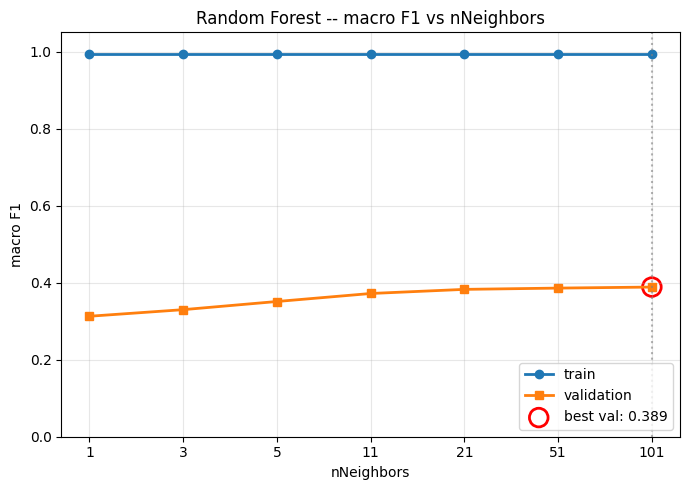


=== Best validation F1 per hyperparameter ===
  nNeighbors          : best=101, val F1=0.3886


In [43]:
sweeperKnn: HyperparameterSweeper = HyperparameterSweeper(
    X_train=X_train_z,
    Y_train=Y_train,
    X_val=X_val_z,
    Y_val=Y_val,
    evaluator=evaluator,
)

sweeperKnn.sweep(
    paramName="nNeighbors",
    paramValues=[1, 3, 5, 11, 21, 51, 101],
    baseParams={"weights": "distance"},
    modelClass=KNNModel,                       # NEW arg from the patched sweeper
)

sweeperKnn.plotAll()
sweeperKnn.printBestValues()

In [44]:
bestK, _ = sweeperKnn.getBestValue("nNeighbors")
print(f"\nBest k from sweep: {bestK}")

knnUniform: KNNModel = KNNModel(
    nNeighbors=bestK,
    weights="uniform",
).fit(X_train_z, Y_train)
knnUniform.tuneThresholds(X_val_z, Y_val)
yPredUniform: np.ndarray = knnUniform.predict(X_val_z)
f1Uniform: float = evaluator.computeMacroF1(Y_val, yPredUniform)
print(f"KNN k={bestK} uniform-weighted: val F1 = {f1Uniform:.4f}")
print(f"KNN k={bestK} distance-weighted (best from sweep): val F1 = "
      f"{sweeperKnn.getBestValue('nNeighbors')[1]:.4f}")


Best k from sweep: 101
KNN k=101 uniform-weighted: val F1 = 0.3833
KNN k=101 distance-weighted (best from sweep): val F1 = 0.3886


In [45]:
sweeperKnn.sweep(
    paramName="nNeighbors",
    paramValues=[101, 201, 301, 501],
    baseParams={"weights": "distance"},
    modelClass=KNNModel,
)


Sweeping nNeighbors over [101, 201, 301, 501]  [KNNModel]
  nNeighbors=     101  train F1=0.9944  val F1=0.3886  (2.3s)
  nNeighbors=     201  train F1=0.9944  val F1=0.3866  (4.7s)
  nNeighbors=     301  train F1=0.9944  val F1=0.3790  (4.8s)
  nNeighbors=     501  train F1=0.9944  val F1=0.3672  (5.2s)


{'param_name': 'nNeighbors',
 'param_values': [101, 201, 301, 501],
 'train_f1': [0.9943888548621238,
  0.9943888548621238,
  0.9943888548621238,
  0.9943888548621238],
 'val_f1': [0.3885906964663979,
  0.38658849160047193,
  0.3790007820154779,
  0.36720573143612534],
 'fit_times': [2.287360191345215,
  4.741970539093018,
  4.8103790283203125,
  5.2034735679626465]}

In [33]:
from typing import Dict, List
import matplotlib.pyplot as plt
import time
import numpy as np


class ModelComparator:
    """
    Trains, tunes, and evaluates multi-label classifiers under a strict
    train / val / test discipline for Part 3.b:

        1. fit(X_train, Y_train)
        2. tuneThresholds(X_val, Y_val)
        3. predict(X_test)  -- test set is read exactly once per model

    Stores per-model results and produces the side-by-side per-class
    F1 plot that goes in the report.
    """

    # ---- constructor ----
    def __init__(
        self,
        X_train:   np.ndarray,
        Y_train:   np.ndarray,
        X_val:     np.ndarray,
        Y_val:     np.ndarray,
        X_test:    np.ndarray,
        Y_test:    np.ndarray,
        evaluator: "MetricEvaluator",
    ) -> None:
        self.X_train:   np.ndarray = X_train
        self.Y_train:   np.ndarray = Y_train
        self.X_val:     np.ndarray = X_val
        self.Y_val:     np.ndarray = Y_val
        self.X_test:    np.ndarray = X_test
        self.Y_test:    np.ndarray = Y_test
        self.evaluator: MetricEvaluator = evaluator

        self.results_: Dict[str, Dict] = {}

    # ---- public API ----
    def evaluate(self, model, name: str) -> Dict:
        """Run the full train/tune/test pipeline for one model."""
        print(f"\n=== {name} ===")

        # 1) train
        tStart: float = time.time()
        model.fit(self.X_train, self.Y_train)
        fitTime: float = time.time() - tStart
        print(f"  fit             : {fitTime:.1f}s")

        # 2) tune thresholds on val
        tStart = time.time()
        model.tuneThresholds(self.X_val, self.Y_val)
        tuneTime: float = time.time() - tStart
        print(f"  threshold tune  : {tuneTime:.1f}s")

        # 3) evaluate on val and test
        yPredVal:  np.ndarray = model.predict(self.X_val)
        yPredTest: np.ndarray = model.predict(self.X_test)

        valMacroF1:  float = self.evaluator.computeMacroF1(self.Y_val,  yPredVal)
        testMacroF1: float = self.evaluator.computeMacroF1(self.Y_test, yPredTest)

        valPerClass:  Dict[str, float] = self.evaluator.computePerClassF1(self.Y_val,  yPredVal)
        testPerClass: Dict[str, float] = self.evaluator.computePerClassF1(self.Y_test, yPredTest)

        print(f"  VAL  macro F1   : {valMacroF1:.4f}")
        print(f"  TEST macro F1   : {testMacroF1:.4f}")

        result: Dict = {
            "name":             name,
            "val_macro_f1":     valMacroF1,
            "test_macro_f1":    testMacroF1,
            "val_per_class":    valPerClass,
            "test_per_class":   testPerClass,
            "fit_time":         fitTime,
            "tune_time":        tuneTime,
        }
        self.results_[name] = result
        return result

    def evaluateBaseline(self, baselineName: str = "Baseline (stratified random)") -> Dict:
        """Evaluate the same stratified-random baseline on the test set."""
        baseline: MultilabelBaseline = MultilabelBaseline(
            strategy=BaselineStrategy.STRATIFIED_RANDOM, seed=42,
        ).fit(self.X_train, self.Y_train)

        yPredVal:  np.ndarray = baseline.predict(self.X_val)
        yPredTest: np.ndarray = baseline.predict(self.X_test)

        valMacroF1:  float = self.evaluator.computeMacroF1(self.Y_val,  yPredVal)
        testMacroF1: float = self.evaluator.computeMacroF1(self.Y_test, yPredTest)

        valPerClass:  Dict[str, float] = self.evaluator.computePerClassF1(self.Y_val,  yPredVal)
        testPerClass: Dict[str, float] = self.evaluator.computePerClassF1(self.Y_test, yPredTest)

        print(f"\n=== {baselineName} ===")
        print(f"  VAL  macro F1   : {valMacroF1:.4f}")
        print(f"  TEST macro F1   : {testMacroF1:.4f}")

        result: Dict = {
            "name":           baselineName,
            "val_macro_f1":   valMacroF1,
            "test_macro_f1":  testMacroF1,
            "val_per_class":  valPerClass,
            "test_per_class": testPerClass,
        }
        self.results_[baselineName] = result
        return result

    def printSummary(self) -> None:
        print(f"\n{'='*70}")
        print(f"{'Model':<40s}{'val F1':>12s}{'test F1':>12s}")
        print("-" * 70)
        for name, r in self.results_.items():
            print(f"{name:<40s}{r['val_macro_f1']:>12.4f}{r['test_macro_f1']:>12.4f}")
        print("=" * 70)

    def plotPerClassComparison(self) -> None:
        """Side-by-side per-class F1 bar chart on the test set."""
        if not self.results_:
            raise RuntimeError("call evaluate(...) first")

        numModels: int = len(self.results_)
        x: np.ndarray = np.arange(len(CLASSES_NAMES))
        width: float = 0.8 / numModels

        fig, ax = plt.subplots(figsize=(14, 6))
        colors: List[str] = ["steelblue", "coral", "grey", "olive", "purple"]

        for i, (name, r) in enumerate(self.results_.items()):
            f1Values: List[float] = [r["test_per_class"][cls] for cls in CLASSES_NAMES]
            offset:   float       = (i - (numModels - 1) / 2) * width
            ax.bar(
                x + offset,
                f1Values,
                width,
                label=f"{name}  (macro={r['test_macro_f1']:.3f})",
                color=colors[i % len(colors)],
            )

        ax.set_xticks(x)
        ax.set_xticklabels(CLASSES_NAMES, rotation=45, ha="right")
        ax.set_ylabel("Test-set F1")
        ax.set_title("Per-class F1 on test set")
        ax.set_ylim(0.0, 1.0)
        ax.legend(loc="upper right")
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()


=== Random Forest ===
  fit             : 114.3s
  threshold tune  : 0.7s
  VAL  macro F1   : 0.4475
  TEST macro F1   : 0.4221

=== KNN ===
  fit             : 0.0s
  threshold tune  : 4.1s
  VAL  macro F1   : 0.3886
  TEST macro F1   : 0.3659

=== Baseline (stratified random) ===
  VAL  macro F1   : 0.0552
  TEST macro F1   : 0.0548

Model                                         val F1     test F1
----------------------------------------------------------------------
Random Forest                                 0.4475      0.4221
KNN                                           0.3886      0.3659
Baseline (stratified random)                  0.0552      0.0548


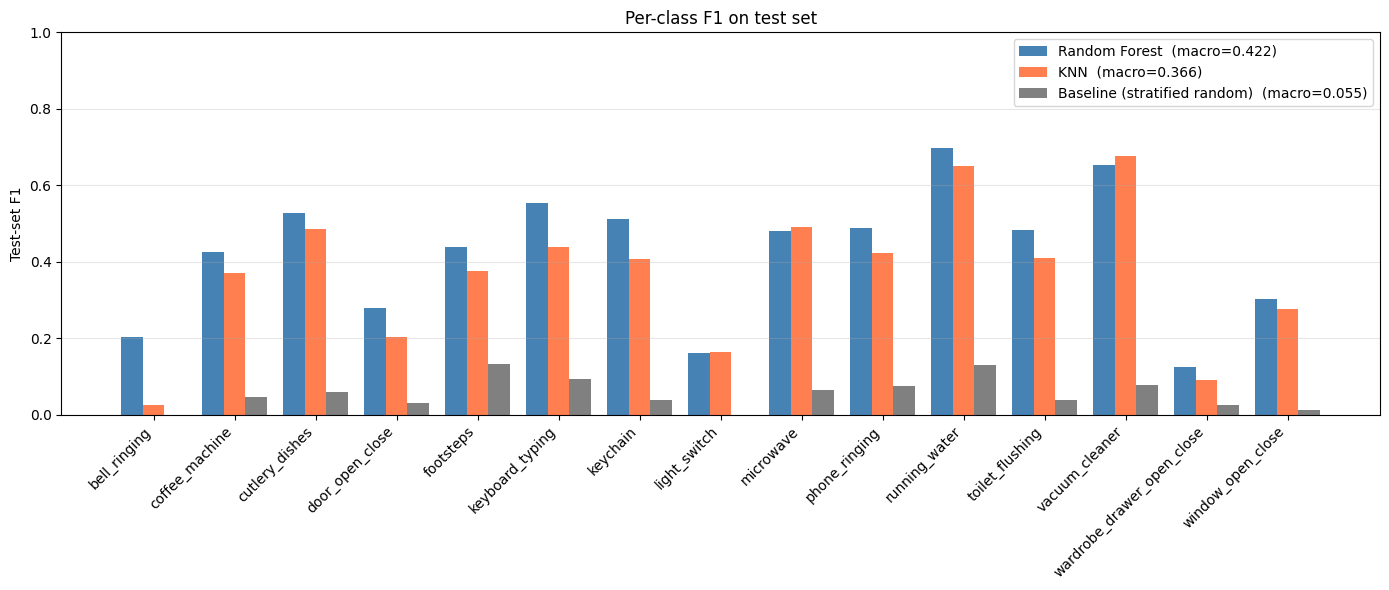

In [34]:
comparator: ModelComparator = ModelComparator(
    X_train=X_train_z,  Y_train=Y_train,
    X_val=X_val_z,      Y_val=Y_val,
    X_test=X_test_z,    Y_test=Y_test,
    evaluator=evaluator,
)

# --- final Random Forest configuration (from 3.a sweeps) ---
finalRF: RandomForestModel = RandomForestModel(
    nEstimators=200,
    maxDepth=None,
    minSamplesLeaf=1,
)
comparator.evaluate(finalRF, name="Random Forest")

# --- final KNN configuration (from 3.a sweeps) ---
finalKNN: KNNModel = KNNModel(
    nNeighbors=101,
    weights="distance",
)
comparator.evaluate(finalKNN, name="KNN")

# --- baseline for context ---
comparator.evaluateBaseline()

# --- summary table + plot ---
comparator.printSummary()
comparator.plotPerClassComparison()

In [36]:
from sklearn.metrics import confusion_matrix
from typing import Dict, List
import matplotlib.pyplot as plt
import numpy as np


class PerClassAnalyzer:
    """
    Per-class confusion analysis for multi-label predictions.

    Two views:

      1) Per-class 2x2 confusion matrices, one per class, in a 3x5 grid.
         Each matrix shows TN / FP / FN / TP counts for one class.

      2) Co-prediction heatmap [C, C] where cell (i, j) is the fraction
         of segments truly containing class i in which class j was
         predicted active. The diagonal is per-class recall; the
         off-diagonal reveals which classes get confused.
    """

    # ---- constructor ----
    def __init__(
        self,
        Y_true:     np.ndarray,
        Y_pred:     np.ndarray,
        classNames: List[str],
    ) -> None:
        if Y_true.shape != Y_pred.shape:
            raise ValueError(f"shape mismatch: {Y_true.shape} vs {Y_pred.shape}")
        if Y_true.shape[1] != len(classNames):
            raise ValueError(
                f"Y has {Y_true.shape[1]} classes, classNames has {len(classNames)}"
            )
        self.Y_true:      np.ndarray = Y_true
        self.Y_pred:      np.ndarray = Y_pred
        self.classNames:  List[str]  = classNames
        self.numClasses_: int        = len(classNames)

    # ---- view 1: per-class confusion matrices ----
    def computePerClassMatrices(self) -> Dict[str, np.ndarray]:
        result: Dict[str, np.ndarray] = {}
        for classIdx, className in enumerate(self.classNames):
            yTrue: np.ndarray = self.Y_true[:, classIdx]
            yPred: np.ndarray = self.Y_pred[:, classIdx]
            cm:    np.ndarray = confusion_matrix(yTrue, yPred, labels=[0, 1])
            result[className] = cm
        return result

    def plotPerClassMatrices(self, modelName: str = "Random Forest") -> None:
        matrices: Dict[str, np.ndarray] = self.computePerClassMatrices()

        fig, axes = plt.subplots(3, 5, figsize=(18, 11))
        axes = axes.flatten()

        for i, (className, cm) in enumerate(matrices.items()):
            ax = axes[i]

            # Row-normalise so 'true 0' and 'true 1' rows are independently
            # comparable -- otherwise the huge TN dominates the colour scale
            cmNorm: np.ndarray = cm.astype(float) / np.maximum(
                cm.sum(axis=1, keepdims=True), 1
            )

            im = ax.imshow(cmNorm, cmap="Blues", vmin=0, vmax=1)
            ax.set_title(className, fontsize=10)
            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels(["pred 0", "pred 1"], fontsize=8)
            ax.set_yticklabels(["true 0", "true 1"], fontsize=8)

            # Annotate every cell with the absolute count
            for r in range(2):
                for c in range(2):
                    count: int  = int(cm[r, c])
                    color: str  = "white" if cmNorm[r, c] > 0.5 else "black"
                    ax.text(
                        c, r, str(count),
                        ha="center", va="center",
                        color=color, fontsize=10,
                    )

        plt.suptitle(
            f"Per-class confusion matrices on test set — {modelName}",
            fontsize=14, y=1.00,
        )
        plt.tight_layout()
        plt.show()

    # ---- view 2: co-prediction heatmap ----
    def computeCoPredictionRates(self) -> np.ndarray:
        """
        Returns [C, C] matrix.
            cell (i, j) = P(class j predicted = 1 | class i truly present)
            diagonal    = recall for class i
        """
        rates: np.ndarray = np.zeros(
            (self.numClasses_, self.numClasses_), dtype=np.float64
        )
        for trueIdx in range(self.numClasses_):
            trueMask: np.ndarray = (self.Y_true[:, trueIdx] == 1)
            numTrue:  int        = int(trueMask.sum())
            if numTrue == 0:
                continue
            for predIdx in range(self.numClasses_):
                numCoPred: int = int(self.Y_pred[trueMask, predIdx].sum())
                rates[trueIdx, predIdx] = numCoPred / numTrue
        return rates

    def plotCoPredictionRates(self, modelName: str = "Random Forest") -> None:
        rates: np.ndarray = self.computeCoPredictionRates()

        fig, ax = plt.subplots(figsize=(12, 10))
        im = ax.imshow(rates, cmap="Blues", vmin=0, vmax=1)

        ax.set_xticks(range(self.numClasses_))
        ax.set_yticks(range(self.numClasses_))
        ax.set_xticklabels(self.classNames, rotation=45, ha="right")
        ax.set_yticklabels(self.classNames)
        ax.set_xlabel("Predicted class j")
        ax.set_ylabel("True class i  (segments where class i is present)")
        ax.set_title(
            f"P(class j predicted | class i truly present) — {modelName}\n"
            "diagonal = recall;  off-diagonal = co-prediction / confusion"
        )

        for i in range(self.numClasses_):
            for j in range(self.numClasses_):
                value: float = rates[i, j]
                if value >= 0.05:
                    color: str = "white" if value > 0.5 else "black"
                    ax.text(
                        j, i, f"{value:.2f}",
                        ha="center", va="center",
                        color=color, fontsize=8,
                    )

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    # ---- text summary for the report ----
    def printSummary(self) -> None:
        matrices: Dict[str, np.ndarray] = self.computePerClassMatrices()
        print(
            f"\n{'class':<32s}{'TN':>7s}{'FP':>7s}{'FN':>7s}{'TP':>7s}"
            f"{'precision':>12s}{'recall':>10s}{'F1':>10s}"
        )
        print("-" * 95)
        for className, cm in matrices.items():
            tn: int = int(cm[0, 0])
            fp: int = int(cm[0, 1])
            fn: int = int(cm[1, 0])
            tp: int = int(cm[1, 1])

            precision: float = tp / max(tp + fp, 1)
            recall:    float = tp / max(tp + fn, 1)
            f1:        float = (
                2 * precision * recall / max(precision + recall, 1e-10)
            )
            print(
                f"{className:<32s}{tn:>7d}{fp:>7d}{fn:>7d}{tp:>7d}"
                f"{precision:>12.3f}{recall:>10.3f}{f1:>10.3f}"
            )

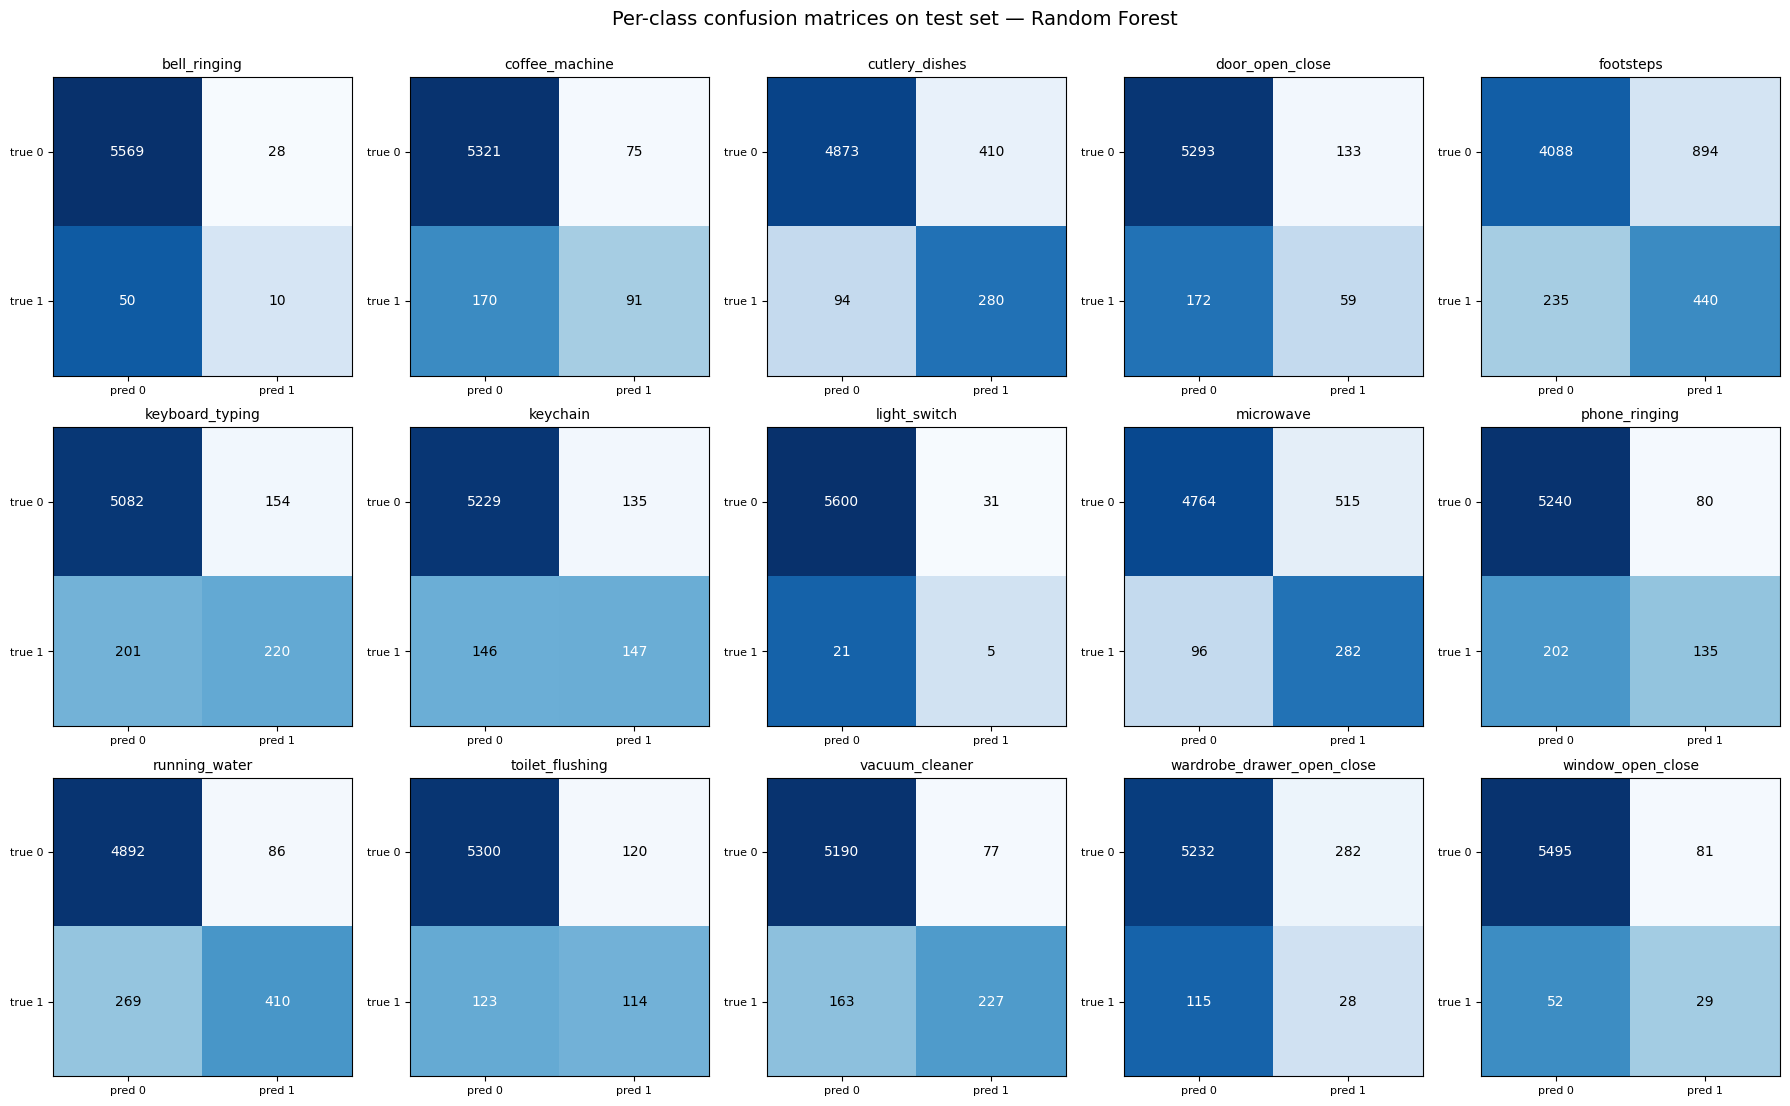

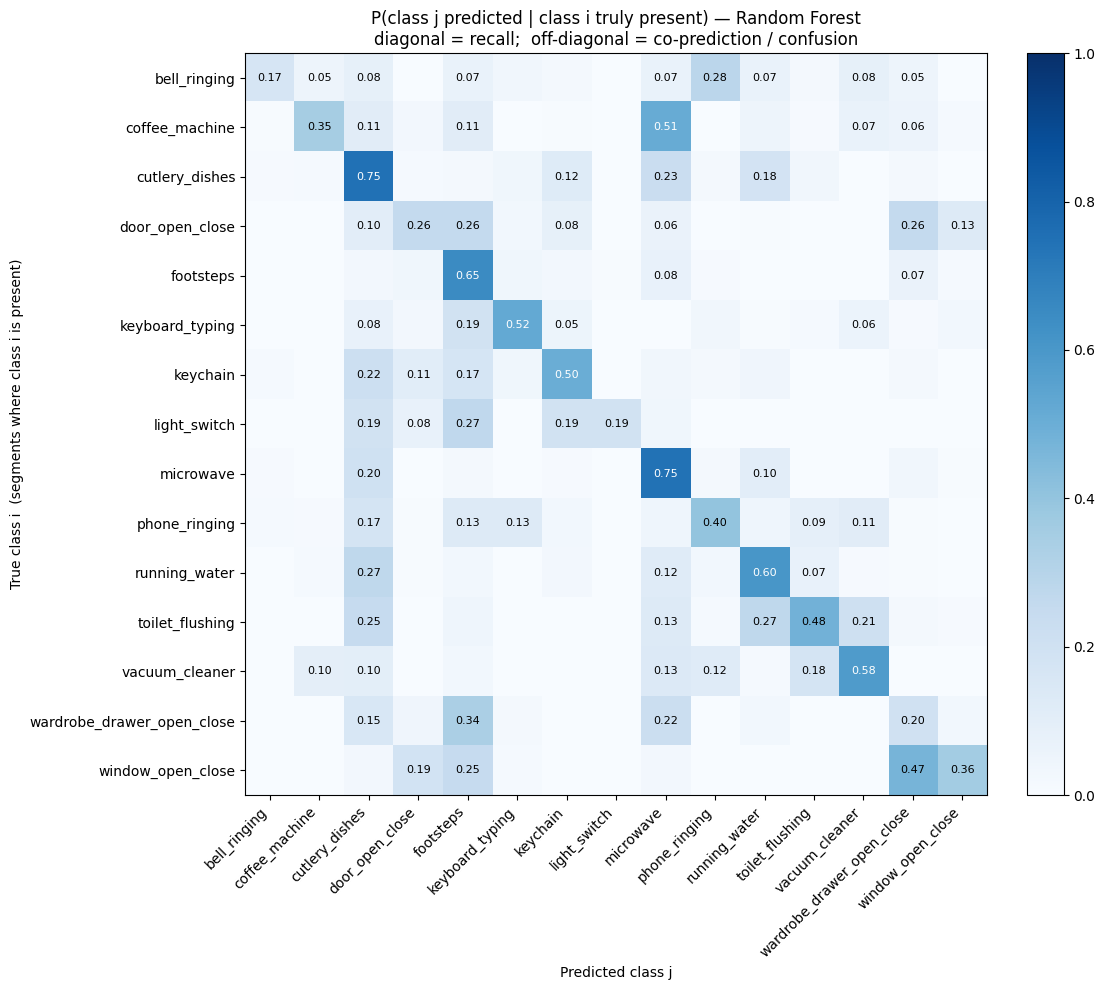


class                                TN     FP     FN     TP   precision    recall        F1
-----------------------------------------------------------------------------------------------
bell_ringing                       5569     28     50     10       0.263     0.167     0.204
coffee_machine                     5321     75    170     91       0.548     0.349     0.426
cutlery_dishes                     4873    410     94    280       0.406     0.749     0.526
door_open_close                    5293    133    172     59       0.307     0.255     0.279
footsteps                          4088    894    235    440       0.330     0.652     0.438
keyboard_typing                    5082    154    201    220       0.588     0.523     0.553
keychain                           5229    135    146    147       0.521     0.502     0.511
light_switch                       5600     31     21      5       0.139     0.192     0.161
microwave                          4764    515     96    282      

In [49]:
# Use the same RF that the comparator just trained and tuned -- thresholds
# are already set, so predict() gives the test-set predictions we evaluated.
yPredTestRF: np.ndarray = finalRF.predict(X_test_z)

analyzer: PerClassAnalyzer = PerClassAnalyzer(
    Y_true=Y_test,
    Y_pred=yPredTestRF,
    classNames=CLASSES_NAMES,
)

# --- main figure for the report: 3x5 grid of 2x2 matrices ---
analyzer.plotPerClassMatrices(modelName="Random Forest")

# --- secondary figure: class-ambiguity heatmap ---
analyzer.plotCoPredictionRates(modelName="Random Forest")

# --- numerical summary ---
analyzer.printSummary()

In [37]:
from sklearn.metrics import f1_score
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import numpy as np


class CaseStudyVisualizer:
    """
    Visualizes per-segment predictions vs. ground truth for a single
    audio file. Produces a three-panel figure:
        1. Mel spectrogram (aggregated melspect_mean from the .npz file)
        2. Ground-truth label timeline (time x class heatmap)
        3. Predicted label timeline   (time x class heatmap)

    Selection helper: scores every candidate file by per-file macro F1
    and returns a ranked list, so we can pick one strong example and
    one failure case for the report.
    """

    # ---- constructor ----
    def __init__(
        self,
        finalModel,                  # the trained + threshold-tuned RandomForestModel
        normalizer,                  # the fit FeatureNormalizer
        aggregator,                  # the LabelAggregator used during training
        featureNames: List[str],     # FEATURE_NAMES from the tutorial
        classNames:   List[str],     # CLASSES_NAMES from the tutorial
    ) -> None:
        self.finalModel    = finalModel
        self.normalizer    = normalizer
        self.aggregator    = aggregator
        self.featureNames  = featureNames
        self.classNames    = classNames

    # ---- public API ----
    def loadAndPredict(self, npzPath: str) -> Dict:
        """Build features, aggregate labels, predict, return everything."""
        data = dict(np.load(npzPath, allow_pickle=True))

        # ground-truth labels
        Y_true: np.ndarray = self.aggregator.aggregate(data["annotations"])

        # feature matrix (same packing as get_features_and_targets)
        T: int = data["annotations"].shape[0]
        totalDim: int = sum(
            data[f].shape[1] if data[f].ndim > 1 else 1
            for f in self.featureNames
        )
        x: np.ndarray = np.empty((T, totalDim))
        col: int = 0
        for featName in self.featureNames:
            feat = data[featName]
            width: int = feat.shape[1] if feat.ndim > 1 else 1
            x[:, col:col + width] = feat if feat.ndim > 1 else feat[:, None]
            col += width

        # standardize + predict
        x_z:    np.ndarray = self.normalizer.transform(x)
        Y_pred: np.ndarray = self.finalModel.predict(x_z)

        return {
            "path":       npzPath,
            "melspect":   data["melspect_mean"],   # [T, 128]
            "start_time": data["start_time"],
            "Y_true":     Y_true,
            "Y_pred":     Y_pred,
        }

    def computePerFileMacroF1(self, fileData: Dict) -> float:
        return float(f1_score(
            fileData["Y_true"], fileData["Y_pred"],
            average="macro", zero_division=0,
        ))

    def rankFiles(
        self,
        candidatePaths: List[str],
    ) -> List[Tuple[str, float, int]]:
        """
        Returns a list of (path, macro_f1, num_positive_segments)
        sorted by F1 descending. Files with no positive ground-truth
        segments are skipped (they have no labels to evaluate).
        """
        scored: List[Tuple[str, float, int]] = []
        for path in candidatePaths:
            try:
                fd = self.loadAndPredict(path)
                numPositive: int = int(fd["Y_true"].sum())
                if numPositive == 0:
                    continue
                f1: float = self.computePerFileMacroF1(fd)
                scored.append((path, f1, numPositive))
            except Exception as e:
                print(f"  skipping {path}: {e}")
        scored.sort(key=lambda t: t[1], reverse=True)
        return scored

    def plot(self, fileData: Dict, title: str = "") -> None:
        timeAxis: np.ndarray = fileData["start_time"]
        tMin:     float      = float(timeAxis[0])
        tMax:     float      = float(timeAxis[-1])

        fig, axes = plt.subplots(
            3, 1, figsize=(14, 9), sharex=True,
            gridspec_kw={"height_ratios": [2.0, 1.5, 1.5]},
        )

        # --- panel 1: mel spectrogram in dB ---
        melspect_db: np.ndarray = 10 * np.log10(
            np.maximum(fileData["melspect"].T, 1e-10)
        )
        axes[0].imshow(
            melspect_db, aspect="auto", origin="lower",
            extent=[tMin, tMax, 0, 128], cmap="viridis",
        )
        axes[0].set_ylabel("mel band")
        axes[0].set_title(f"{title} -- mel spectrogram (1\\,s windows, dB)")

        # --- panel 2 + 3: label heatmaps ---
        self._plotLabelHeatmap(axes[1], fileData["Y_true"], tMin, tMax,
                                "Ground-truth labels")
        self._plotLabelHeatmap(axes[2], fileData["Y_pred"], tMin, tMax,
                                "Predicted labels")
        axes[2].set_xlabel("time (s)")

        plt.tight_layout()
        return fig

    # ---- private ----
    def _plotLabelHeatmap(self, ax, labels, tMin, tMax, title):
        ax.imshow(
            labels.T,
            aspect="auto", origin="lower",
            extent=[tMin, tMax, -0.5, len(self.classNames) - 0.5],
            cmap="Blues", vmin=0, vmax=1, interpolation="nearest",
        )
        ax.set_yticks(range(len(self.classNames)))
        ax.set_yticklabels(self.classNames, fontsize=8)
        ax.set_title(title)

In [38]:
caseStudy: CaseStudyVisualizer = CaseStudyVisualizer(
    finalModel=finalRF,
    normalizer=normalizer,
    aggregator=aggregator,
    featureNames=FEATURE_NAMES,
    classNames=CLASSES_NAMES,
)

# Rank every test-split file by how well the model performed on it
print("Ranking test-set files by per-file macro F1 ...")
rankings = caseStudy.rankFiles(splits["test"])

print("\nTop 5 (model handles well):")
for path, f1, npos in rankings[:5]:
    print(f"  F1={f1:.3f}  positives={npos:>4d}  {path}")

print("\nBottom 5 (model struggles):")
for path, f1, npos in rankings[-5:]:
    print(f"  F1={f1:.3f}  positives={npos:>4d}  {path}")

Ranking test-set files by per-file macro F1 ...

Top 5 (model handles well):
  F1=0.223  positives=  42  /home/sophie/MachienPattern/MLPC2026_dataset_development/audio_features/005378.npz
  F1=0.181  positives=  49  /home/sophie/MachienPattern/MLPC2026_dataset_development/audio_features/001401.npz
  F1=0.178  positives=  32  /home/sophie/MachienPattern/MLPC2026_dataset_development/audio_features/001392.npz
  F1=0.176  positives=  76  /home/sophie/MachienPattern/MLPC2026_dataset_development/audio_features/001066.npz
  F1=0.173  positives=  49  /home/sophie/MachienPattern/MLPC2026_dataset_development/audio_features/002654.npz

Bottom 5 (model struggles):
  F1=0.013  positives=   9  /home/sophie/MachienPattern/MLPC2026_dataset_development/audio_features/004072.npz
  F1=0.008  positives=  42  /home/sophie/MachienPattern/MLPC2026_dataset_development/audio_features/002868.npz
  F1=0.008  positives=  18  /home/sophie/MachienPattern/MLPC2026_dataset_development/audio_features/001653.npz
  F1=0

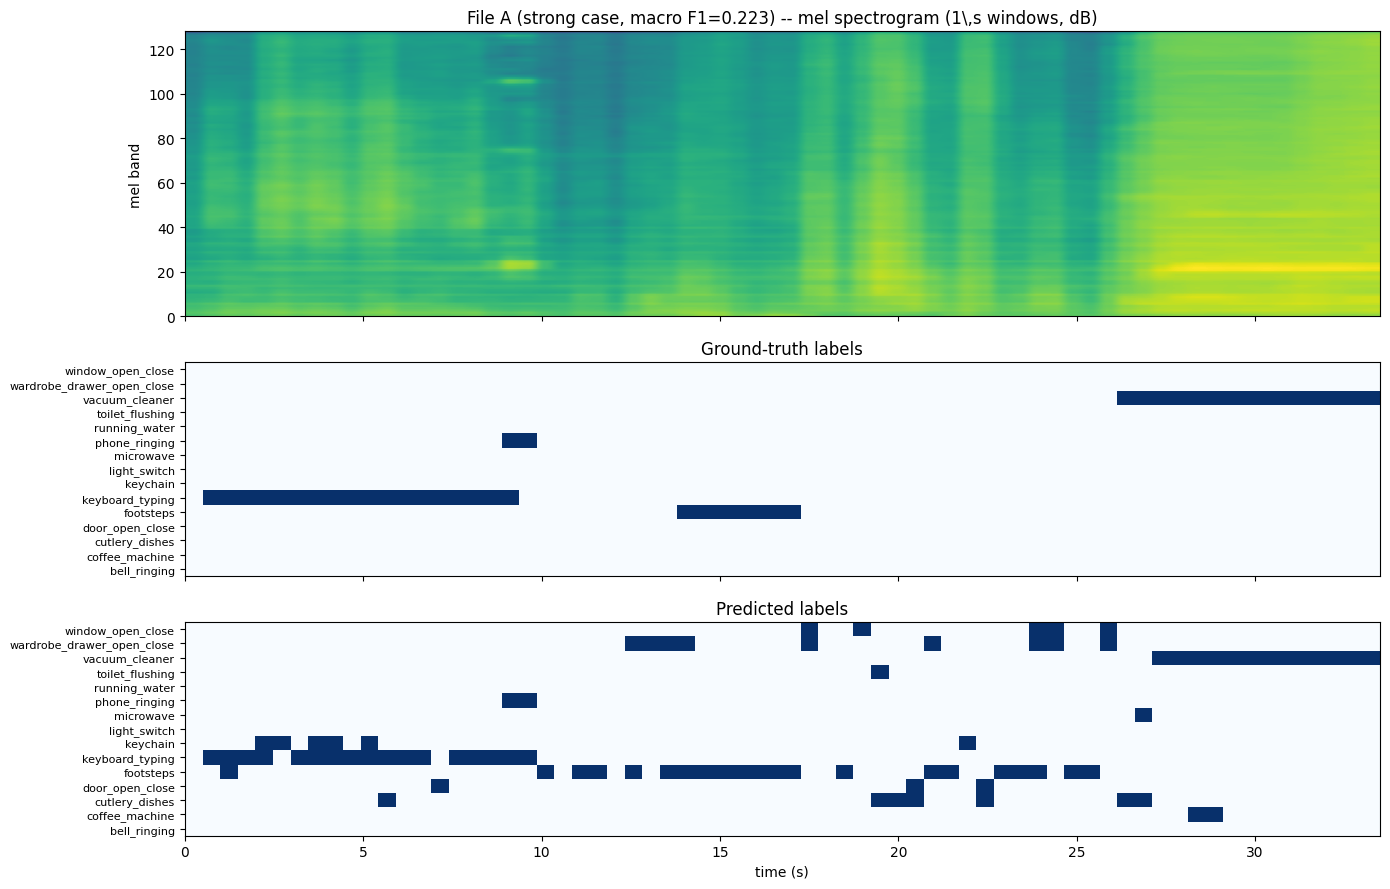

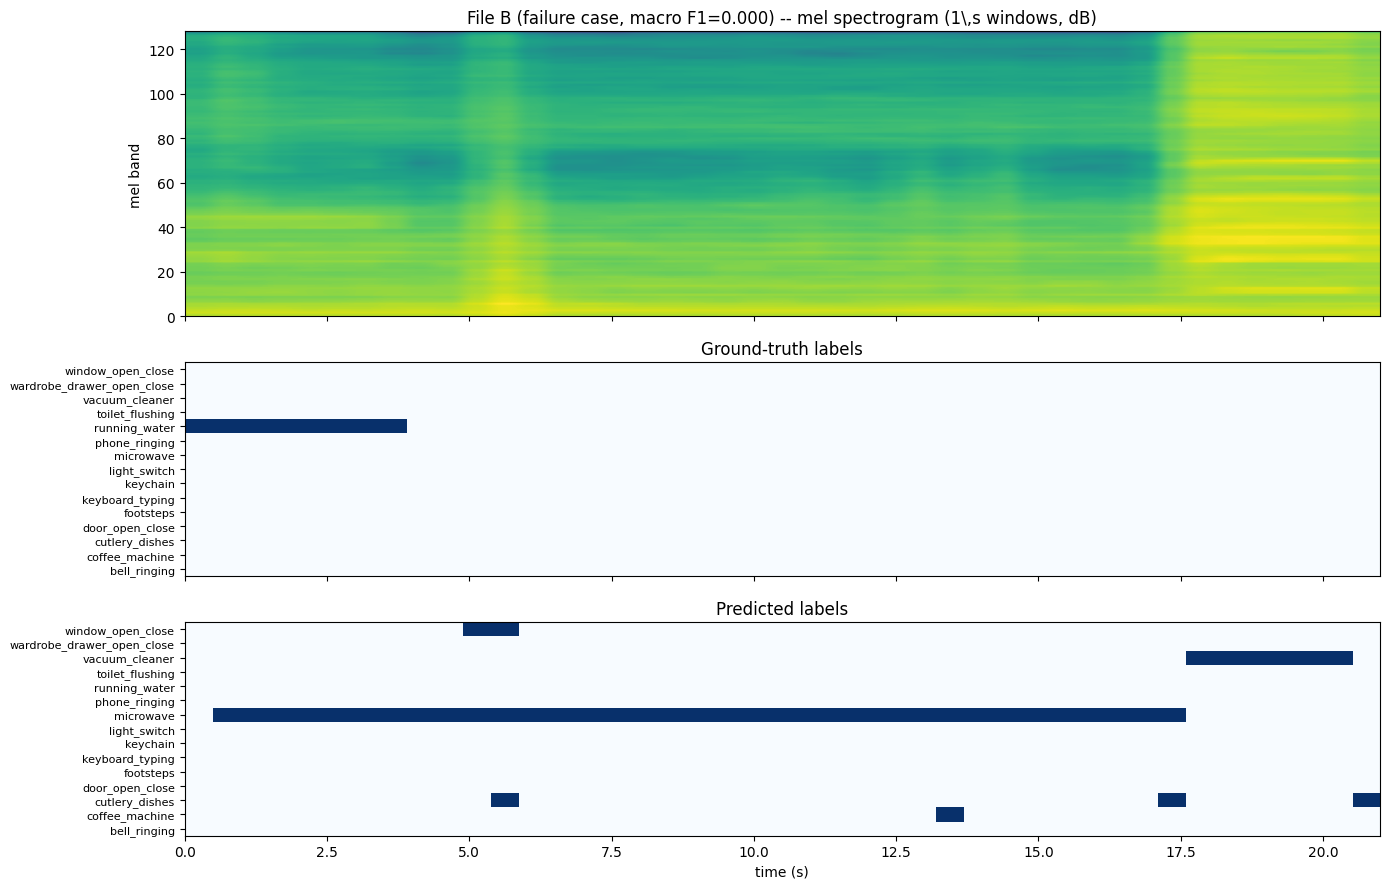

In [41]:
# Replace these with the actual paths from your rankings output
pathGood: str = rankings[0][0]    # top file
pathBad:  str = rankings[-1][0]   # bottom file

fileA = caseStudy.loadAndPredict(pathGood)
fileB = caseStudy.loadAndPredict(pathBad)

caseStudy.plot(fileA, title=f"File A (strong case, macro F1={rankings[0][1]:.3f})")
plt.savefig("figures/case_study_A.png", dpi=150, bbox_inches="tight")

caseStudy.plot(fileB, title=f"File B (failure case, macro F1={rankings[-1][1]:.3f})")
plt.savefig("figures/case_study_B.png", dpi=150, bbox_inches="tight")

In [ ]:
OLD

In [18]:
#old
def read_files(
    file_list: List[str],
    label_type: Literal["binary", "multiclass", "multilabel"] = "multilabel",
) -> Tuple[np.ndarray, Union[np.ndarray, Dict[str, np.ndarray]]]:
    """Load and stack features and labels from a list of .npz files.

    Parameters
    ----------
    file_list : list of str
        Paths to .npz audio feature files to load.
    label_type : {"binary", "multiclass", "multilabel"}
        Passed through to ``get_features_and_targets``; controls the format of
        the returned labels.

    Returns
    -------
    X : np.ndarray of shape (N, D)
        Stacked feature matrix across all files.
    Y : np.ndarray of shape (N, C) or (N, 1), or Dict[str, np.ndarray]
        Stacked labels in the format specified by ``label_type``.
    """
    if label_type not in ("binary", "multiclass", "multilabel"):
        raise ValueError(
            f"`label_type` must be 'binary', 'multiclass', or 'multilabel', got {label_type!r}"
        )
    X = []
    Y = []

    for filename in file_list:
        x, y = get_features_and_targets(filename, label_type=label_type)
        X.append(x)
        Y.append(y)

    X = np.vstack(X)

    if label_type == "binary":
        return X, {cls: np.vstack([y[cls] for y in Y]) for cls in CLASSES_NAMES}
    else:
        return X, np.vstack(Y)

### Task 0: Baseline Classifier

**Implementation Task**: Create a binary classifier that predicts the class that is most frequent in the training dataset. You can find our solution below.

In [19]:
class BaselineClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self):
        self.majority_class = None

    def fit(self, x_train: np.ndarray, y_train: np.ndarray) -> None:
        """Fit the classifier by finding the majority class.

        Parameters
        ----------
        x_train : np.ndarray of shape (N, D)
            Feature matrix with N samples and D dimensions. Not used directly,
            included for API consistency.
        y_train : np.ndarray of shape (N,)
            Binary labels (0 or 1) for each training sample.

        Raises
        ------
        NotImplementedError
            This method must be implemented by the student.
        """
        raise NotImplementedError

    def predict(self, x: np.ndarray) -> np.ndarray:
        """Predict binary labels for each sample.

        Parameters
        ----------
        x : np.ndarray of shape (N, D)
            Feature matrix with N samples and D dimensions.

        Returns
        -------
        predictions : np.ndarray of shape (N,)
            Predicted binary labels (all equal to the majority class).

        Raises
        ------
        NotImplementedError
            This method must be implemented by the student.
        """
        raise NotImplementedError

In [21]:
# solution
class BaselineClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self):
        self.majority_class = None

    def fit(self, x_train: np.ndarray, y_train: np.ndarray) -> None:
        """Fit the classifier by finding the majority class.

        Parameters
        ----------
        x_train : np.ndarray of shape (N, D)
            Feature matrix with N samples and D dimensions. Not used directly,
            included for API consistency.
        y_train : np.ndarray of shape (N,)
            Binary labels (0 or 1) for each training sample.
        """
        self.classes_ = np.unique(y_train)
        self.majority_class = 1 if sum(y_train) > len(y_train) / 2 else 0

    def predict(self, x: np.ndarray) -> np.ndarray:
        """Predict binary labels for each sample.

        Parameters
        ----------
        x : np.ndarray of shape (N, D)
            Feature matrix with N samples and D dimensions.

        Returns
        -------
        predictions : np.ndarray of shape (N,)
            Predicted binary labels (all equal to the majority class).
        """
        predictions = np.zeros(x.shape[0]) + self.majority_class
        return predictions

Let's use our baseline classifier to predict whether a sound is a bell ringing or not:

In [22]:
X_train, Y_train = read_files(audio_features_paths, label_type="binary")
bell_x, bell_y = X_train, Y_train["bell_ringing"]

In [23]:
baseline = BaselineClassifier()
baseline.fit(bell_x, bell_y)

y_train_pred = baseline.predict(bell_x)

train_fraction_correct = np.mean(y_train_pred == bell_y)

print(f"Training Fraction Correct: {train_fraction_correct:.2f}")

Training Fraction Correct: 0.98


The resulting accuracy is very how. But does this mean our baseline classifier is good?

Actually not. The high accuracy is a result of label imbalance. Can you already think of better ways to estimate the model performance? (**Hint**: check `01_classification_metrics.ipynb`)

## 3. Data Split

Would looking into the model's predictions on the whole dataset give us a good estimation of how well it has learned something?
You may remember the KNN classifier from the lecture. Let's see how it performs on the following simple dataset:

In [48]:
def plot_decision_boundary(
    knn: KNeighborsClassifier,
    X: np.ndarray,
    y: np.ndarray,
    title: str,
    highlight_point: Optional[np.ndarray] = None,
) -> None:
    """Plot the decision boundary of a classifier over a 2-D feature space.

    Parameters
    ----------
    knn : KNeighborsClassifier
        Fitted sklearn classifier with a ``predict`` method.
    X : np.ndarray of shape (N, 2)
        2-D feature matrix used for training.
    y : np.ndarray of shape (N,)
        Class labels corresponding to each row of ``X``.
    title : str
        Title for the plot.
    highlight_point : np.ndarray of shape (1, 2), optional
        An additional point to mark with a star (e.g., a test example).
    """
    h = 0.1
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(5, 3))
    plt.contourf(xx, yy, Z, cmap="coolwarm", alpha=0.3)

    # Negative class (0)
    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        color="blue",
        edgecolor="k",
        s=100,
        label="Negative",
    )

    # Positive class (1)
    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        color="red",
        edgecolor="k",
        s=100,
        label="Positive",
    )

    if highlight_point is not None:
        plt.scatter(
            highlight_point[0][0],
            highlight_point[0][1],
            color="gold",
            edgecolor="k",
            marker="*",
            s=250,
            label="Test point (positiv)",
        )

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()

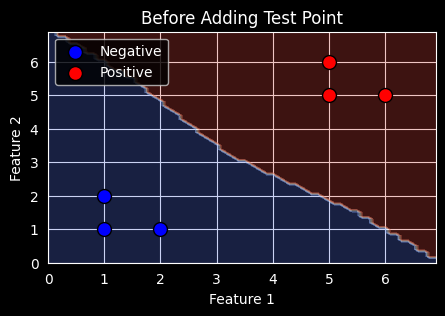

In [49]:
X_train = np.array(
    [[1, 1], [1, 2], [2, 1], [5, 5], [5, 6], [6, 5]]  # Class 0  # Class 1
)
y_train = np.array([0, 0, 0, 1, 1, 1])

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

plot_decision_boundary(knn, X_train, y_train, "Before Adding Test Point")

The classes seem to be perfectly separated. Assuming the model works perfectly, we deploy it in a real world setting, and the first new data comes in:

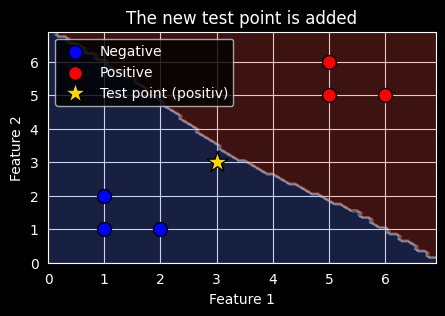

In [50]:
test_point = np.array([[3, 3]])
true_label = np.array([1])

pred_before = knn.predict(test_point)

plot_decision_boundary(
    knn, X_train, y_train, "The new test point is added", highlight_point=test_point
)

So, the predictions of the model may not be as good as we expect.

### Test Set & Information Leakage

To get a more realistic estimation of how a model is performing, we can put a part of the dataset aside and look at how the model performs on this set. The sklearn library has a function for this [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

Let's repeat the experiment on our own dataset for class wind:

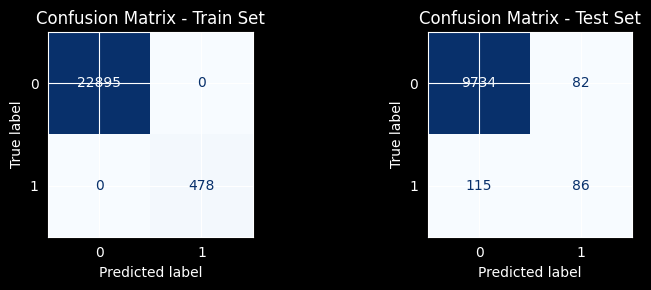

In [42]:
# Split data
X_train_bell, X_test_bell, y_train_bell, y_test_bell = train_test_split(
    bell_x,
    bell_y,
    test_size=0.3,
    random_state=42,
)

# Train model
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_bell, y_train_bell.reshape(-1))

# Predictions
y_train_pred = knn.predict(X_train_bell)
y_test_pred = knn.predict(X_test_bell)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 3))  # Side by side, smaller overall size

# Train confusion matrix
cm_train = confusion_matrix(y_train_bell, y_train_pred)
disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_train, display_labels=knn.classes_
)
disp_train.plot(cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix - Train Set")

# Test confusion matrix
cm_test = confusion_matrix(y_test_bell, y_test_pred)
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test, display_labels=knn.classes_
)
disp_test.plot(cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix - Test Set")

plt.tight_layout()
plt.show()

Assuming that the distribution of our data matches that of the "real data", this will usually give us a better estimation of how the model performs. But this is still not quite accurate for a dataset similar to ours, due to a problem referred to as data leakage.

Data leakage occurs when a model has access to information during training that would not be available at prediction time, leading to overly optimistic performance. Why is this problem relevant to us?

train_test_split splits the data randomly. If you apply it directly on the frame level, frames from the same original audio file may end up in both the training and test sets.

Since consecutive frames are highly correlated (they come from the same source), this violates the assumption that the test set is unseen data. As a result:

The model might "memorize" patterns from specific files and the evaluation metrics will be overly optimistic and misleading.

### Task 1: Avoiding Information Leakage in your Data Splits

**Implementation Task**: Split our dataset into training and test sets, making sure that all frames from the same original audio file end up in the same set. You can find our solution below.

In [43]:
# raise NotImplementedError
# train_files = TODO
# test_files = TODO

# X_train, Y_train = read_files(train_files, label_type="binary")
# X_test, Y_test = read_files(test_files, label_type="binary")

In [44]:
# solution
train_files = audio_features_paths[: int(len(audio_features_paths) * 0.8)]
test_files = audio_features_paths[int(len(audio_features_paths) * 0.8) :]

X_train, Y_train = read_files(train_files, label_type="binary")
X_test, Y_test = read_files(test_files, label_type="binary")

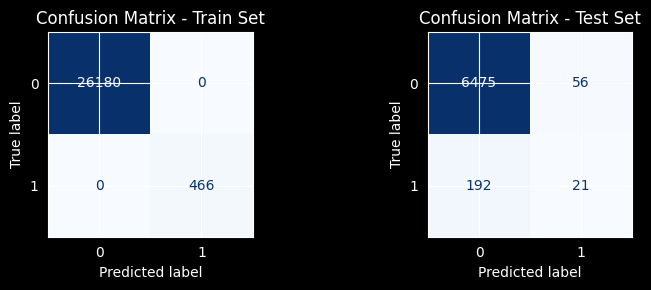

In [46]:
bell_x_train, bell_y_train = X_train, Y_train["bell_ringing"]
bell_x_test, bell_y_test = X_test, Y_test["bell_ringing"]

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(bell_x_train, bell_y_train.reshape(-1))

y_train_pred = knn.predict(bell_x_train)
y_test_pred = knn.predict(bell_x_test)


# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 3))  # Side by side, smaller overall size

# Train confusion matrix
cm_train = confusion_matrix(bell_y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_train, display_labels=knn.classes_
)
disp_train.plot(cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix - Train Set")

# Test confusion matrix
cm_test = confusion_matrix(bell_y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test, display_labels=knn.classes_
)
disp_test.plot(cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix - Test Set")

plt.tight_layout()
plt.show()

### Validation Set

We have tried two models so far. Often when training a classifier we consider different model classes, and each with a set of hyper-parameters.

Could we use the performance on the test set to choose the best classifier?

No, the test set must not be used to choose the best classifier or to tune hyperparameters. Doing so leads to information leakage and overestimates the model's true performance.

The test set is our unseen data. If we select the model class and hyperparameters based on test performance, the model has indirectly seen the test data and the evaluation becomes unreliable. To avoid this, we put aside another section of data as the validation set.

In [51]:
train_files = audio_features_paths[: int(len(audio_features_paths) * 0.7)]
validation_files = audio_features_paths[
    int(len(audio_features_paths) * 0.7) : int(len(audio_features_paths) * 0.9)
]
test_files = audio_features_paths[int(len(audio_features_paths) * 0.9) :]

# So final split: 70% train, 20% val, 10% test

## Performance Metrics

See `01_classification_metrics.ipynb` for a more thorough description of the metrics. This is just a quick recap.

| Metric                   | Description                                                 | When It's Useful                                                       |
| ------------------------ | ----------------------------------------------------------- | ---------------------------------------------------------------------- |
| **Accuracy**             | % of correct predictions `(TP + TN) / Total`                | Simple, but **misleading with imbalanced data**                        |
| **Precision**            | How many predicted positives were correct: `TP / (TP + FP)` | Important when **false positives** are costly (e.g., spam filters)     |
| **Recall (Sensitivity)** | How many actual positives were caught: `TP / (TP + FN)`     | Critical when **false negatives** are costly (e.g., medical diagnosis) |
| **F1 Score**             | Harmonic mean of precision and recall                       | Good **balance** when classes are imbalanced                           |
| **ROC AUC**              | Measures ranking ability over all thresholds                | Good for **probabilistic models**; not sensitive to threshold          |
| **PR AUC**               | Area under Precision-Recall curve                           | Better than ROC AUC for **imbalanced data**                            |


In [53]:
# y_true: ground truth labels
# y_pred: predicted class labels (e.g., 0 or 1)
# y_scores: predicted probabilities or decision function scores

accuracy = accuracy_score(bell_y_test, y_test_pred)
precision = precision_score(bell_y_test, y_test_pred, zero_division=0)
recall = recall_score(bell_y_test, y_test_pred)
f1 = f1_score(bell_y_test, y_test_pred)
roc_auc = roc_auc_score(bell_y_test, y_test_pred)
pr_auc = average_precision_score(bell_y_test, y_test_pred)
weighted_acc = balanced_accuracy_score(bell_y_test, y_test_pred)

print(f"Accuracy:         {accuracy:.3f}")
print(f"Weighted Accuracy:{weighted_acc:.3f}")
print(f"Precision:        {precision:.3f}")
print(f"Recall:           {recall:.3f}")
print(f"F1 Score:         {f1:.3f}")
print(f"ROC AUC:          {roc_auc:.3f}")
print(f"PR AUC:           {pr_auc:.3f}")

Accuracy:         0.963
Weighted Accuracy:0.545
Precision:        0.273
Recall:           0.099
F1 Score:         0.145
ROC AUC:          0.545
PR AUC:           0.055


## 4. Binary Classification

Now we can move on to training classifiers. Let's start be training a very simple Decision Tree.
A **Decision Tree** is a model that splits data by asking feature-based questions, forming a tree structure.  

In [69]:
X_train, Y_train = read_files(train_files, label_type="binary")
X_test, Y_test = read_files(test_files, label_type="binary")
X_val, Y_val = read_files(validation_files, label_type="binary")

print(len(X_train))
# subsampling the training data to reduce run time
sample_size = 5000
indices = np.random.choice(len(X_train), size=sample_size, replace=False)

X_train = X_train[indices]
for c in CLASSES_NAMES:
    Y_train[c] = Y_train[c][indices]


bell_x_train, bell_y_train = X_train, Y_train["bell_ringing"]
bell_x_test, bell_y_test = X_test, Y_test["bell_ringing"]
bell_x_val, bell_y_val = X_val, Y_val["bell_ringing"]

23311


In [79]:
# Define the model
dt = DecisionTreeClassifier(random_state=42)

The DT classifier has several patameters we can experiment with. Let's pick a few to explore

In [80]:
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
}
best_score = 0
best_params = None
best_model = None

In [82]:
import numpy as np

max_depths = param_grid["max_depth"]
min_splits = param_grid["min_samples_split"]

# Create result containers
scores_gini = np.zeros((len(max_depths), len(min_splits)))
scores_entropy = np.zeros((len(max_depths), len(min_splits)))

for i, max_depth in enumerate(max_depths):
    for j, min_samples_split in enumerate(min_splits):
        for criterion in param_grid["criterion"]:

            model = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                criterion=criterion,
                random_state=42,
            )
            model.fit(bell_x_train, bell_y_train)

            y_val_pred = model.predict(bell_x_val)
            score = balanced_accuracy_score(bell_y_val, y_val_pred)

            print(
                f"Params: max_depth={max_depth}, min_samples_split={min_samples_split}, criterion={criterion} --> Accuracy: {score:.4f}"
            )

            # Store score
            if criterion == "gini":
                scores_gini[i, j] = score
            else:
                scores_entropy[i, j] = score

            # Track best
            if score > best_score:
                best_score = score
                best_params = {
                    "max_depth": max_depth,
                    "min_samples_split": min_samples_split,
                    "criterion": criterion,
                }
                best_model = model

Params: max_depth=3, min_samples_split=2, criterion=gini --> Accuracy: 0.5766
Params: max_depth=3, min_samples_split=2, criterion=entropy --> Accuracy: 0.5358
Params: max_depth=3, min_samples_split=5, criterion=gini --> Accuracy: 0.5766
Params: max_depth=3, min_samples_split=5, criterion=entropy --> Accuracy: 0.5358
Params: max_depth=3, min_samples_split=10, criterion=gini --> Accuracy: 0.5766
Params: max_depth=3, min_samples_split=10, criterion=entropy --> Accuracy: 0.5358
Params: max_depth=5, min_samples_split=2, criterion=gini --> Accuracy: 0.5971
Params: max_depth=5, min_samples_split=2, criterion=entropy --> Accuracy: 0.5435
Params: max_depth=5, min_samples_split=5, criterion=gini --> Accuracy: 0.5971
Params: max_depth=5, min_samples_split=5, criterion=entropy --> Accuracy: 0.5435
Params: max_depth=5, min_samples_split=10, criterion=gini --> Accuracy: 0.5971
Params: max_depth=5, min_samples_split=10, criterion=entropy --> Accuracy: 0.5438
Params: max_depth=10, min_samples_split=2,

In [83]:
import matplotlib.pyplot as plt

def plot_heatmap(scores, title):
    plt.figure(figsize=(6, 4))
    im = plt.imshow(scores, cmap="viridis")

    plt.colorbar(im)

    plt.xticks(range(len(min_splits)), min_splits)
    plt.yticks(range(len(max_depths)), max_depths)

    plt.xlabel("min_samples_split")
    plt.ylabel("max_depth")
    plt.title(title)

    # Annotate values
    for i in range(len(max_depths)):
        for j in range(len(min_splits)):
            plt.text(j, i, f"{scores[i, j]:.3f}",
                     ha="center", va="center", color="white")

    plt.tight_layout()
    plt.show()

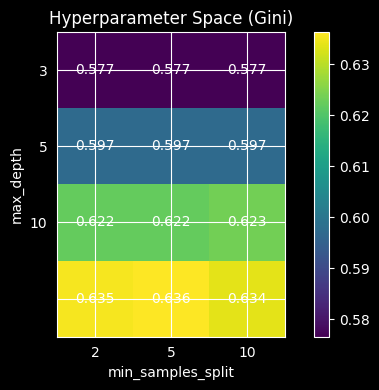

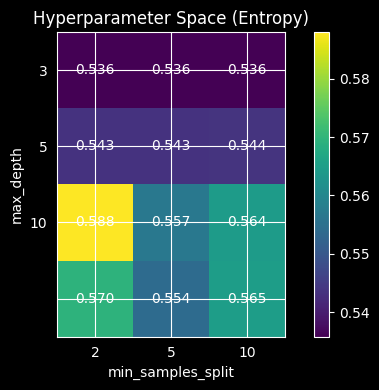

In [84]:
plot_heatmap(scores_gini, "Hyperparameter Space (Gini)")
plot_heatmap(scores_entropy, "Hyperparameter Space (Entropy)")

## 5. Multi-Label Classification

The classifiers we looked into were all **binary** classifiers, and simply distinguish if a datapoint belongs in a class or not. Among non-binary classification problems, two common sets of classes are **Multi-Label Classification** and **Multi-Class Classification**.

- Multi-Class: We have n possible classes, where each instance belongs to exactly one class.
- Multi-Label: We have n possible classes, and each instance can belong to multiple classes (or none).  

Which description fits our task better?

In our dataset we have a set of sound events that can happen simultaneously and in the same audio frame. This turns our problem into a multi-label classification problem.
One simple was of performing this type of classification is to have one binary classifier per class, working independently. Let's see how this works in practice.

In [85]:
X_train, Y_train = read_files(train_files, label_type="multilabel")
X_test, Y_test = read_files(test_files, label_type="multilabel")
X_val, Y_val = read_files(validation_files, label_type="multilabel")

# subsampling the training data to reduce run time
sample_size = 5000
indices = np.random.choice(len(X_train), size=sample_size, replace=False)

X_train = X_train[indices]
Y_train = Y_train[indices]

In [88]:
selected_classes = ["bell_ringing", "vacuum_cleaner"]
selected_indices = [CLASSES_NAMES.index(cls) for cls in selected_classes]

y_train = Y_train[:, selected_indices]
y_val = Y_val[:, selected_indices]
y_test = Y_test[:, selected_indices]

In [89]:
y_train.shape

(5000, 2)

### Baseline Classifier

Before training a proper classifier, let's establish a majority-class baseline for two classes (`["bell_ringing", "vacuum_cleaner"]`) simultaneously.

Sklearn provides a wrapper for classifiers that do not natively support multi-target classification: `MultiOutputClassifier`. This wrapper classifier works by fitting one classifier per target class and making predictions independently for each target. We could achieve the same by training multiple separate `BaselineClassifier` in a loop; this would also give us the chance to balance the dataset and tune hyperparameters separately. For convenience, we will use `MultiOutputClassifier` as it is more convenient and cleaner.

Let's wrap the `BaselineClassifier` into a `MultiOutputClassifier` and evaluate its performance on all classes on the validation set.

In [90]:
baseline_clf = MultiOutputClassifier(BaselineClassifier())
baseline_clf.fit(X_train, y_train)
Y_pred_baseline = baseline_clf.predict(X_val)

In [91]:
n_labels = y_val.shape[1]
baseline_bal_accs = [
    balanced_accuracy_score(y_val[:, i], Y_pred_baseline[:, i])
    for i in range(n_labels)
]
baseline_accs = [
    accuracy_score(y_val[:, i], Y_pred_baseline[:, i])
    for i in range(n_labels)
]
baseline_bal_acc_macro = np.mean(baseline_bal_accs)
baseline_acc_macro = np.mean(baseline_accs)

print(f"Baseline Macro-Avg Accuracy:          {baseline_acc_macro:.4f}")
print(f"Baseline Macro-Avg Balanced Accuracy: {baseline_bal_acc_macro:.4f}")

Baseline Macro-Avg Accuracy:          0.9516
Baseline Macro-Avg Balanced Accuracy: 0.5000


Let's use a Decision Tree in the same manner, and see how it performs on the validation set.

In [92]:
X = X_train
Y_multilabel = y_train

base_clf = DecisionTreeClassifier()

br_clf = MultiOutputClassifier(base_clf)

br_clf.fit(X, Y_multilabel)

Y_pred_dt = br_clf.predict(X_val)

In [94]:
n_labels = y_val.shape[1]
dt_bal_accs = []
dt_accs = []

for i in range(n_labels):
    dt_bal_accs.append(balanced_accuracy_score(y_val[:, i], Y_pred_dt[:, i]))
    dt_accs.append(accuracy_score(y_val[:, i], Y_pred_dt[:, i]))

dt_bal_acc_macro = np.mean(dt_bal_accs)
dt_acc_macro = np.mean(dt_accs)

print(f"Decision Tree Macro-Avg Accuracy:          {dt_acc_macro:.4f}")
print(f"Decision Tree Macro-Avg Balanced Accuracy: {dt_bal_acc_macro:.4f}")

Decision Tree Macro-Avg Accuracy:          0.9430
Decision Tree Macro-Avg Balanced Accuracy: 0.6972


## Task 2: 
**Implementation Task:** Train a [Random Forest Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) for multi-label classification and report your results. Take a look at the documentation and choose initial hyperparameters that sound reasonable and are suitable for your computational resources. You can find our solution below.

In [95]:
# raise NotImplementedError

In [97]:
# solution

X = X_train
Y_multilabel = y_train

base_clf = RandomForestClassifier(max_depth=10, n_estimators=500, random_state=42)

br_clf = MultiOutputClassifier(base_clf)

br_clf.fit(X, Y_multilabel)

Y_pred_rf = br_clf.predict(X_val)

In [98]:
n_labels = y_val.shape[1]
rf_bal_accs = [
    balanced_accuracy_score(y_val[:, i], Y_pred_rf[:, i])
    for i in range(n_labels)
]
rf_accs = [
    accuracy_score(y_val[:, i], Y_pred_rf[:, i])
    for i in range(n_labels)
]
rf_bal_acc_macro = np.mean(rf_bal_accs)
rf_acc_macro = np.mean(rf_accs)

print(f"Random Forest Macro-Avg Accuracy:          {rf_acc_macro:.4f}")
print(f"Random Forest Macro-Avg Balanced Accuracy: {rf_bal_acc_macro:.4f}")

Random Forest Macro-Avg Accuracy:          0.9680
Random Forest Macro-Avg Balanced Accuracy: 0.6771


### Summary: Classifier Comparison

The table below compares all three classifiers on the validation set for the selected classes (`bell_ringing`, `vacuum_cleaner`). Both metrics are macro-averaged across both classes.

In [99]:
classwise_bal_macro = { n: m for n, m in zip(selected_classes, list(zip(baseline_bal_accs, dt_bal_accs, rf_bal_accs)))}

results = pd.DataFrame(
    {
        "Classifier": ["Baseline (Majority Class)", "Decision Tree", "Random Forest"],
    } | classwise_bal_macro | {
        "Macro-Avg Accuracy": [baseline_acc_macro, dt_acc_macro, rf_acc_macro],
        "Macro-Avg Balanced Accuracy": [baseline_bal_acc_macro, dt_bal_acc_macro, rf_bal_acc_macro],
    }
).set_index("Classifier")

results.round(4)

,bell_ringing,vacuum_cleaner,Macro-Avg Accuracy,Macro-Avg Balanced Accuracy
Classifier,,,,
Baseline (Majority Class),0.5000,0.5000,0.9516,0.5000
Decision Tree,0.6384,0.7560,0.9430,0.6972
Random Forest,0.5465,0.8078,0.9680,0.6771


## 6. Multi-Class Classification

> As we discussed above, the project for this class is a **multi-label** classification problem, **NOT a multi-class one**. The following part of the tutorial is just for completeness, so that you get some hands-on experience with multi-class problems. See `read_files` to see how the labels are aggregated in this case! Feel free to skip this section if you just want to focus on the parts relevant for future tasks of the project.

In **binary classification** a model decides between two outcomes (for example, *bell ringing* vs. *not bell ringing*). In **multi-label classification** each frame can carry several labels at the same time. **Multi-class classification** is a third distinct setting: every input is assigned to exactly one class out of $C$ possible categories, and no frame belongs to two classes simultaneously.

In our dataset we treat each audio frame as belonging to one of **15 sound event labels** (e.g. `keyboard_typing`, `footsteps`, `vacuum_cleaner`, ...). The model must discriminate between all 15 categories at once instead of solving 15 independent yes/no problems.

Key differences from binary classification:

| Aspect | Binary | Multi-Class (here) |
|---|---|---|
| Output | $\{0, 1\}$ | $\{0, 1, \ldots, 14\}$ |
| Balanced accuracy | Average recall over 2 classes | Average recall over all 15 classes |
| Confusion matrix | $2 \times 2$ | $15 \times 15$, revealing which classes are confused |

In [100]:
X_train, Y_train = read_files(train_files, label_type="multiclass")
X_test, Y_test = read_files(test_files, label_type="multiclass")
X_val, Y_val = read_files(validation_files, label_type="multiclass")

# subsample training data to reduce run time
sample_size = 5000
indices = rng.choice(len(X_train), size=sample_size, replace=False)
X_train = X_train[indices]
Y_train = Y_train[indices]

### Majority-Class Baseline

Before training a real classifier it is good practice to establish a **baseline**, the simplest possible model whose score sets the floor that any meaningful classifier must beat.

Here we reuse the same idea as in the binary case: always predict the **most frequent class** in the training set. With 15 unbalanced classes the majority label will dominate predictions, which is exactly why **balanced accuracy** (average per-class recall) is a better metric than raw accuracy here.

In [180]:
class MulticlassBaselineClassifier:

    def __init__(self):
        self.majority_class = None

    def fit(self, x_train: np.ndarray, y_train: np.ndarray) -> None:
        values, counts = np.unique(y_train.ravel(), return_counts=True)
        self.majority_class = values[np.argmax(counts)]

    def predict(self, x: np.ndarray) -> np.ndarray:
        return np.full(x.shape[0], self.majority_class)


baseline_mc = MulticlassBaselineClassifier()
baseline_mc.fit(X_train, Y_train)
Y_pred_baseline = baseline_mc.predict(X_test)

Baseline Balanced Accuracy: 0.0667


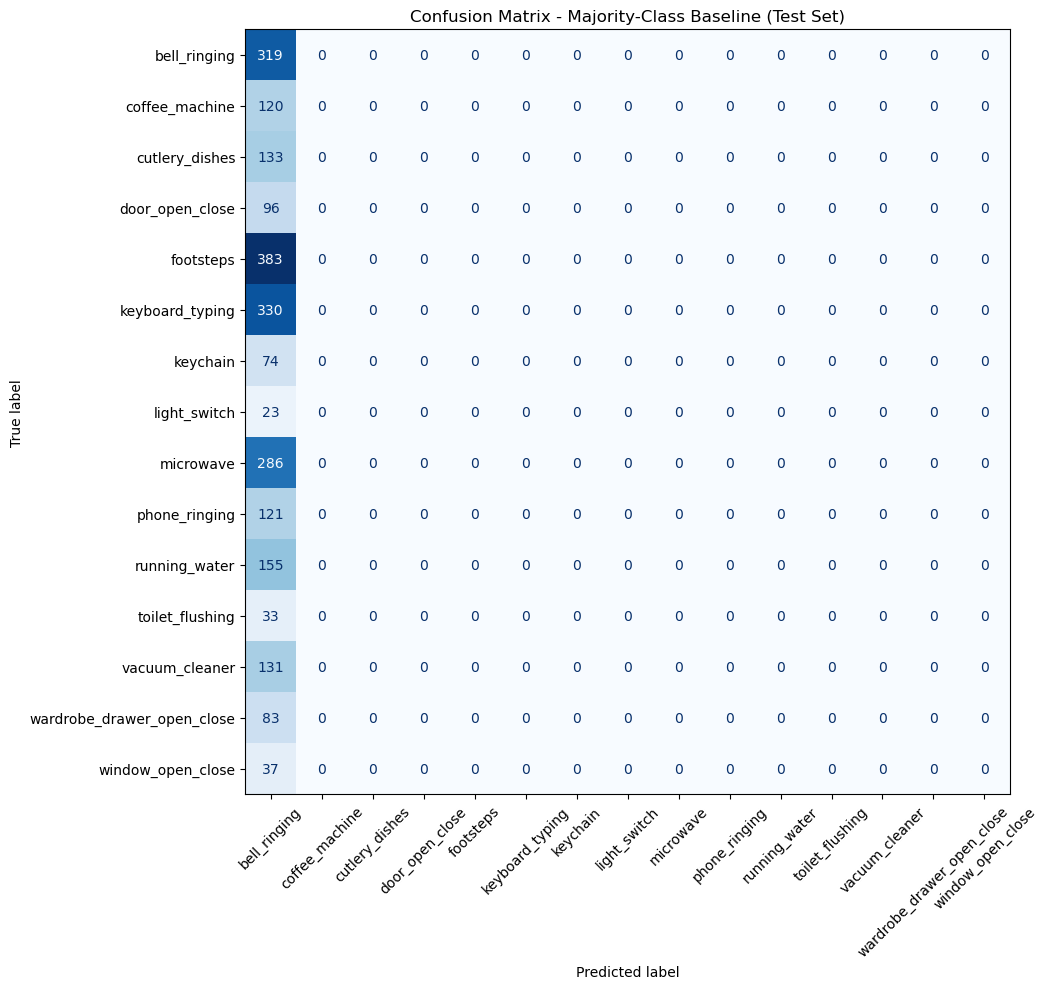

In [181]:
bal_acc_baseline = balanced_accuracy_score(Y_test, Y_pred_baseline)
print(f"Baseline Balanced Accuracy: {bal_acc_baseline:.4f}")

cm_baseline = confusion_matrix(
    Y_test, Y_pred_baseline, labels=range(len(CLASSES_NAMES))
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline, display_labels=CLASSES_NAMES
)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(cmap="Blues", ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix - Majority-Class Baseline (Test Set)")
plt.tight_layout()
plt.show()

### Decision Tree Classifier

Now let's train a proper classifier. A **Decision Tree** recursively partitions the feature space into regions that are as pure as possible with respect to the class labels. Unlike the baseline, it can learn complex, non-linear boundaries across all 15 classes in a single model.

In [182]:
br_clf = DecisionTreeClassifier()

br_clf.fit(X_train, Y_train)

Y_pred = br_clf.predict(X_test)

Balanced Accuracy: 0.1959


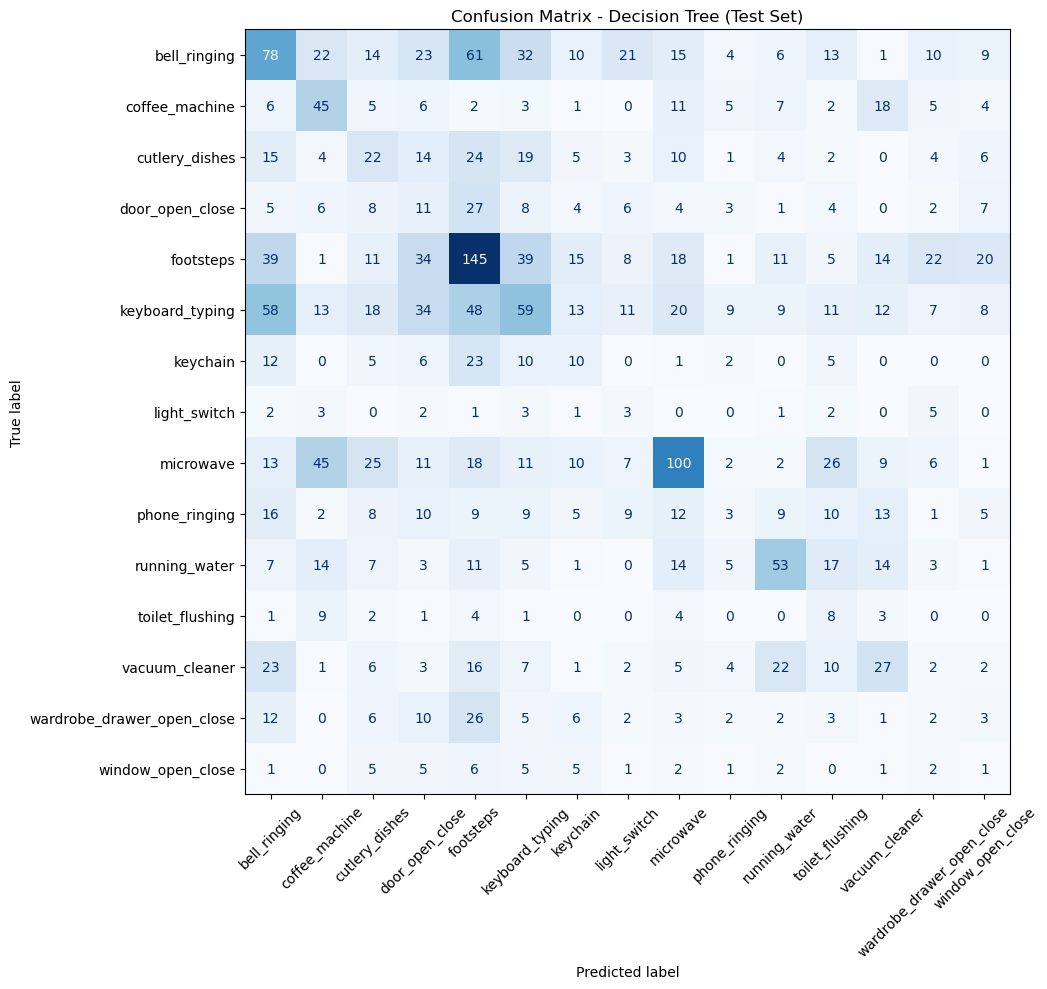

In [183]:
bal_acc = balanced_accuracy_score(Y_test, Y_pred)
print(f"Balanced Accuracy: {bal_acc:.4f}")

cm = confusion_matrix(Y_test, Y_pred, labels=range(len(CLASSES_NAMES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_NAMES)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(cmap="Blues", ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix - Decision Tree (Test Set)")
plt.tight_layout()
plt.show()